In [9]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE,AUC,NDCG,Precision,Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, VAECF
import pandas as pd
import numpy as np
import random
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reader = Reader()
# # file_name= "./cornac/data_c/indexed_interactions.csv"
# file_name= "biased_movie_lens.csv"
# rating_data_pd = pd.read_csv(
#     file_name,
#     sep=",",
#     header=None,
#     names=["_","userID", "itemID", "Rating", "Timestamp", "movieID","genres","Drama","Children's","Action","War","Documentary","Animation","Comedy","Sci-Fi","Romance","Musical","Western","Crime","Thriller","Adventure","Fantasy","Mystery","Film-Noir","Horror","Gender"],
#     dtype={"userID":int, "itemID":int, "Rating":int, "Timestamp":int, "movieID":int,"Drama":float,"Children's":float,"Action":float,"War":float,"Documentary":float,"Animation":float,"Comedy":float,"Sci-Fi":float,"Romance":float,"Musical":float,"Western":float,"Crime":float,"Thriller":float,"Adventure":float,"Fantasy":float,"Mystery":float,"Film-Noir":float,"Horror":float, "Gender":int}
# )
# rating_data = rating_data_pd[["userID","itemID","Rating","Timestamp"]].to_numpy()
# rating_data
# # rating_data = rating_data.drop(columns=rating_data.columns[-1])
# # ,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
# rating_data_pd
# # user id itemid rating and timestamp

In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data

array([[        0,         0,         5, 978300760],
       [        0,         1,         3, 978302109],
       [        0,         2,         3, 978301968],
       ...,
       [     6039,       365,         5, 956704746],
       [     6039,       152,         4, 956715648],
       [     6039,        26,         4, 956715569]])

In [3]:
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data

In [4]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = set("|".join(movies["genres"]).split("|"))
unique_genres = list(unique_genres)

for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
item_feature_modality = FeatureModality(
    features=item_features_numpy, ids=ids, normalized=True
)


users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
# unique_uids = rating_data_pd['userID'].unique()

# users = users[users["userID"].isin(unique_uids)]
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)
user_feature_modality = FeatureModality(
    features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
)

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)
(3416, 18)


In [5]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
movies

,movieID,genres,itemID,Crime,Action,Thriller,War,Documentary,Children's,Musical,...,Mystery,Film-Noir,Adventure,Sci-Fi,Western,Comedy,Fantasy,Animation,Drama,Horror
0,1193,Drama,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,661,Animation|Children's|Musical,1,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,0
2,914,Musical|Romance,2,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,3408,Drama,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2355,Animation|Children's|Comedy,4,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,2833,Romance|War,3411,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3412,3207,Adventure,3412,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3413,3533,Drama,3413,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3414,2777,Drama,3414,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [6]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df


In [7]:
# genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
# genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# # upper_bound = inter_movies.shape[0]
# indices_to_delete = set()
# mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
# mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
# mask_f = inter_movies.index[mask_f]
# mask_m = inter_movies.index[mask_m]
# upper_bound_m = mask_m.__len__()
# upper_bound_f = mask_f.__len__()
# for i in range(100000):
#     rm=random.randint(0, upper_bound_m-1)
#     rf=random.randint(0, upper_bound_f-1)
#     indices_to_delete.add(mask_f[rf])
#     indices_to_delete.add(mask_m[rm])
            
# inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# # sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [8]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]


In [12]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()

alpha_values = [ 0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
# alpha_values=[0,0.5,0.8,1]
alpha_values=[0]
# alpha_values = [0,0.5]
models = []

for i in range(len(alpha_values)):
    models.append(VAECF(
        k=20,
        autoencoder_structure=[100],
        # act_fn="relu",
        # likelihood="bern",
        n_epochs=100,
        batch_size=256,
        learning_rate=0.0001,
        alpha=alpha_values[i],
        top_k=50,
        beta=1,
        name=f"a={alpha_values[i]} vae",
        seed=123,
        verbose=True,
    ))


# models = [model_1, model_2, model_3, model_4, model_5]
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 6039, 6039, 6039]), array([  0,   1,   2, ..., 423, 750, 823]), array([4., 5., 4., ..., 4., 4., 3.]))
Number of users = 6040
Number of items = 3415
Number of ratings = 797275
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50), (5988

 16%|█▌        | 16/100 [00:05<00:31,  2.69it/s, loss=3.81]


KeyboardInterrupt: 

In [82]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 1],
    item_features=item_features_numpy,exclude_unknowns=False
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)


models=[]
alpha_values=[0.5,0]
# for i in range(len(alpha_values)):
#     model = MF(
#     k=20,
#     max_iter=50,
#     learning_rate=0.00001,
#     lambda_reg=0.02,
#     seed=123,
#     name="alpha="+str(alpha_values[i]),
#     backend="pytorch",
#     alpha=alpha_values[i]
#     )    
#     models.append(model)

# model = UserKNN(k=20, seed=123)
# model = UserKNN(k=20, seed=123)
model = UserKNN(k=20, seed=123)
model_1 = ItemKNN(k=20, seed=123)
model_2 = MF(
k=20,
max_iter=50,
learning_rate=0.0001,
lambda_reg=0.02,
seed=123,
name="alpha="+str(alpha_values[1]),
backend="pytorch",
optimizer="sgd",
alpha=alpha_values[1],
) 


models=[model,model_1,model_2]

cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50,ndcg_50,auc,rmse,prec]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
Number of users = 6040
Number of items = 3415
Number of ratings = 797275
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50), (5988, 51), (5987, 52), (5986, 53), (5985, 54), (5983, 55), (5982, 56), (5981, 57), (5980, 58), (5978, 59), (5979, 60), (5977, 61), (5976,

100%|██████████| 6040/6040 [01:21<00:00, 74.06it/s] 



[UserKNN] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [05:38<00:00, 17.83it/s]



[ItemKNN] Training started!
nnnnnnnnn
<class 'numpy.ndarray'>
nnnnnnnnn


...


[alpha=0] Training started!


100%|██████████| 50/50 [02:48<00:00,  3.36s/it, loss=0.00458]



[alpha=0] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [00:02<00:00, 2064.35it/s]


TEST:
...
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9401 | 0.6282 |  0.0242 |       0.0186 |    0.0383 |   82.3433 | 349.5500
ItemKNN | 1.0119 | 0.6211 |  0.0476 |       0.0358 |    0.0438 |  961.9244 | 191.6263
alpha=0 | 1.0809 | 0.5786 |  0.1137 |       0.0683 |    0.1281 |  168.2389 |   4.0259



In [ ]:
          |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
alpha=0   | 1.0738 | 0.5781 |  0.0651 |       0.0433 |    0.0619 |  265.6354 |   2.8158
alpha=0.3 | 1.0739 | 0.5719 |  0.0625 |       0.0413 |    0.0588 |   89.6387 |   2.9407
alpha=0.5 | 1.0740 | 0.5642 |  0.0579 |       0.0371 |    0.0537 |   89.0614 |   3.5518
alpha=0.7 | 1.0740 | 0.5504 |  0.0444 |       0.0265 |    0.0392 |   87.0882 |   2.8338
alpha=0.8 | 1.0741 | 0.5389 |  0.0300 |       0.0182 |    0.0264 |  672.8500 |   2.8299

new dataset



# item knn no modificatin
        |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9469 | 0.6237 |  0.0103 |       0.0121 |    0.0103 |    1.8950 | 159.0414

# after adding item genres
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
ItemKNN | 1.0084 | 0.5599 |  0.0173 |       0.0133 |    0.0203 |  156.3764 | 116.4956


# after adding user info
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9339 | 0.6007 |  0.0072 |       0.0041 |    0.0154 |   33.4947 | 123.2689


#------------------
          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0   | 1.0809 | 0.5798 |  0.1018 |    0.0635 |  152.5753 |   3.6027
alpha=0.8 | 1.0847 | 0.5844 |  0.1024 |    0.0645 |  211.1065 |   4.3291

          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0.3 | 1.0823 | 0.5800 |  0.1016 |    0.0640 |  772.8089 |   3.6702
alpha=0.5 | 1.0832 | 0.5806 |  0.1018 |    0.0644 |  169.9725 |   4.7815

for (m-f)^2
#------------------


In [ ]:
# # choose movies that are only available in the biased subset
# unique_iids = rating_data_pd['itemID'].unique()
# unique_uids = rating_data_pd['userID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
# users = users[users["userID"].isin(unique_uids)]
# # 
# users
# # cols_to_select = unique_genres +["itemID", "genres"]
# # new_movies = new_movies[cols_to_select]

In [83]:
user_ids = users.to_numpy()[:, 0]
item_ids = movies.to_numpy()[:, 2]
user_ids.__len__()

6040

In [7]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)
reco_matrix_all_scores = np.zeros((len(user_ids), len(item_ids)), dtype=int)
reco_matrix_all_items = np.zeros((len(user_ids), len(item_ids)), dtype=int)

for i in range(len(user_ids)):
    reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
    reco_matrix[i] = reco_items[:top_k]
    reco_matrix_all_scores[i] = all_scores
    reco_matrix_all_items[i] = reco_items

In [73]:
reco_matrix_reco = np.zeros((len(user_ids),top_k), dtype=int)

for i in range(len(user_ids)):
    reco_matrix_reco[i] = models[0].recommend(user_ids[i])[:top_k]



In [42]:
reco_matrix_reco[0]

array([3227, 3384, 3124, 2788, 3344, 2608, 3305, 2997, 1115, 3349,  372,
        259,   23, 2887, 2900,  167, 2504, 2682, 3322,  693,  184,    7,
       2618,   38,   14, 2602, 3410,  127,  611,   47, 1288, 3224,  831,
         37,  723,  726,   45,  236, 1921, 2792, 2463, 1494, 1448,   39,
         29,    0,  355, 1451, 2692,   44])

In [63]:
reco_matrix_reco[0]

array([  44,  127,  132,  104,    5,  209,  669,   38,  167,   97,  259,
        217,  213,  128,  273,  134,  184,   22,  124,   40,  206,  151,
         23,   48,  600,   64,    0,   50, 1158,    9,  186,   26,  434,
        210,  199,  116,   51,  611,  244,   78,  113,  189,  766,  547,
         13,   92,  629,   68,  714, 1115])

In [64]:
reco_matrix_new = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(len(user_ids)):
    reco_matrix_new[i] = reco_matrix_reco[i][:top_k]

reco_matrix_new

array([[  44,  127,  132, ...,   68,  714, 1115],
       [  44,  127,  132, ...,   68,  714, 1115],
       [  44,  127,  132, ...,   68,  714, 1115],
       ...,
       [  44,  127,  132, ...,   68,  714, 1115],
       [  44,  127,  132, ...,   68, 1115,  714],
       [  44,  127,  132, ...,   68,  714,  321]])

In [85]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)
reco_matrix_mapped_scores = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=float)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(user_idx=u, item_indices=list(item_ids))
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

In [92]:
reco_matrix_mapped_scores[0]

array([[4.45632463, 4.41957025, 3.60074865, ..., 2.98981322, 5.39523199,
        0.72047733],
       [4.26161584, 4.44257111, 3.1418885 , ..., 3.27722829, 5.67524398,
        1.05751117],
       [4.03754292, 4.52379895, 3.45899834, ..., 3.46827008, 3.9375    ,
        1.26588927],
       ...,
       [3.98324402, 3.80860678, 2.89689531, ..., 2.74751161, 5.1856388 ,
        0.5126289 ],
       [4.11947454, 3.84562302, 3.36104167, ..., 3.09433557, 5.5064291 ,
        0.83647227],
       [4.10275895, 3.93886392, 3.45349663, ..., 3.30484765, 5.72475268,
        1.1058036 ]])

In [93]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

###intialize them 
gp = GenrePrecision(users, unique_genres)
gr = GenreRecall(users, unique_genres)
gm = GenreMap(users, unique_genres)
gndcg = GenreNDCG(users, unique_genres)
gmrr = GenreMRR(users, unique_genres)

In [95]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models),len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [96]:
reco_matrix_top_r[0][0]

array([3227, 3384, 3124, 2788, 3344,  372, 3305, 2608, 2997, 1115,  184,
       3349,  127, 2887, 2900,   23,  167,  259, 2618, 2682, 2504,  128,
       3322,   47,  693,   14,  831,    7, 2514,    0,  611, 1448, 3410,
        505, 2696, 2792, 1288, 1494,   37, 3224, 1520, 2508, 1608,   68,
         45, 1921,  535, 2602, 1450, 2463, 2617,   29,   34, 1194, 2567,
        716,  236, 1447,  506, 1105,   84,  531, 2465, 2516, 2620,   48,
       2718, 1534, 1461,   39,  723, 1545, 2177,  338, 1182,   38,  726,
       2555,   44,  539, 2227, 2916,  719, 2000, 3402, 2692,   13,  649,
          8, 1158, 2754,  863,  266, 2706, 1049, 2470, 3238, 3397,  960,
        420, 1987, 1451, 1046, 2028, 1064, 2475, 1287,    6,  665,  140,
       2998, 3087,  950, 2914, 3075,  530,  752,  672, 1092, 2987,   40,
        245,  355,  917,  406,  153, 1948, 1584, 2212,  770,  661,  743,
        412,  199,  557,  417, 3271,  374, 1558, 1585,  497,  255, 1794,
        105,  515, 1900,  342,  213, 2474, 2604,  5

In [76]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((len(user_ids), new_top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_top_r[i] = models[0].recommend(user_ids[i])[:new_top_k]


# grp = GenreRPrecision(users, unique_genres)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [111]:
####IR Metrics####
####Precision####
model_gp = gp.compute(reco_matrix[0], movies)
model_gp_2 = gp.compute(reco_matrix[1], movies)
model_gp_3 = gp.compute(reco_matrix[2], movies)

####IR Metrics####
####Recall####
model_gr = gr.compute(reco_matrix[0], movies)
model_gr_2 = gr.compute(reco_matrix[1], movies)
model_gr_3 = gr.compute(reco_matrix[2], movies)
####IR Metrics####
####MAP Mean Average Precision####
model_gm = gm.compute(reco_matrix[0], movies)
model_gm_2 = gm.compute(reco_matrix[1], movies)
model_gm_3 = gm.compute(reco_matrix[2], movies)
####IR Metrics####
####DCG####
model_gdcg = gndcg.compute(reco_matrix[0], movies)
model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
model_gdcg_3 = gndcg.compute(reco_matrix[2], movies)
####IR Metrics####
####MRR####
model_gmrr = gmrr.compute(reco_matrix[0], movies)
model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)
model_gmrr_3 = gmrr.compute(reco_matrix[2], movies)

         Romance    Comedy     Drama   Musical    Action       War  Thriller  \
Gender                                                                         
0       0.003674  0.040903  0.129557  0.000994  0.013051  0.007611  0.014853   
1       0.006913  0.043207  0.130504  0.001935  0.005800  0.003974  0.016931   

        Children's  Documentary  Animation  Adventure    Sci-Fi   Western  \
Gender                                                                      
0         0.001218     0.009065   0.004031   0.006390  0.004776  0.001229   
1         0.001492     0.019171   0.007689   0.004343  0.002181  0.003263   

          Horror     Crime   Mystery   Fantasy  Film-Noir  
Gender                                                     
0       0.003863  0.006530  0.003952  0.000454   0.005805  
1       0.001242  0.003382  0.003245  0.000557   0.002126  
         Romance    Comedy     Drama   Musical    Action       War  Thriller  \
Gender                                            

In [28]:
model_gmrr

array([5.74555801e-04, 4.53348432e-04, 5.72241164e-04, 1.67959258e-04,
       1.56710149e-03, 6.53485826e-04, 1.00364412e-03, 5.25721467e-05,
       2.22945874e-03, 9.01211682e-04, 3.55190363e-04, 5.47194241e-04,
       3.50466465e-04, 4.85581234e-04, 5.73733602e-04, 2.28386090e-04,
       1.15779177e-05, 7.61880553e-04])

In [29]:
print(0.003674-    0.006913)

-0.0032389999999999997


In [32]:
print(0.056189 -0.055617)

0.0005720000000000031


In [98]:

# ####IR Metrics####
# ####Rprecision####
model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)

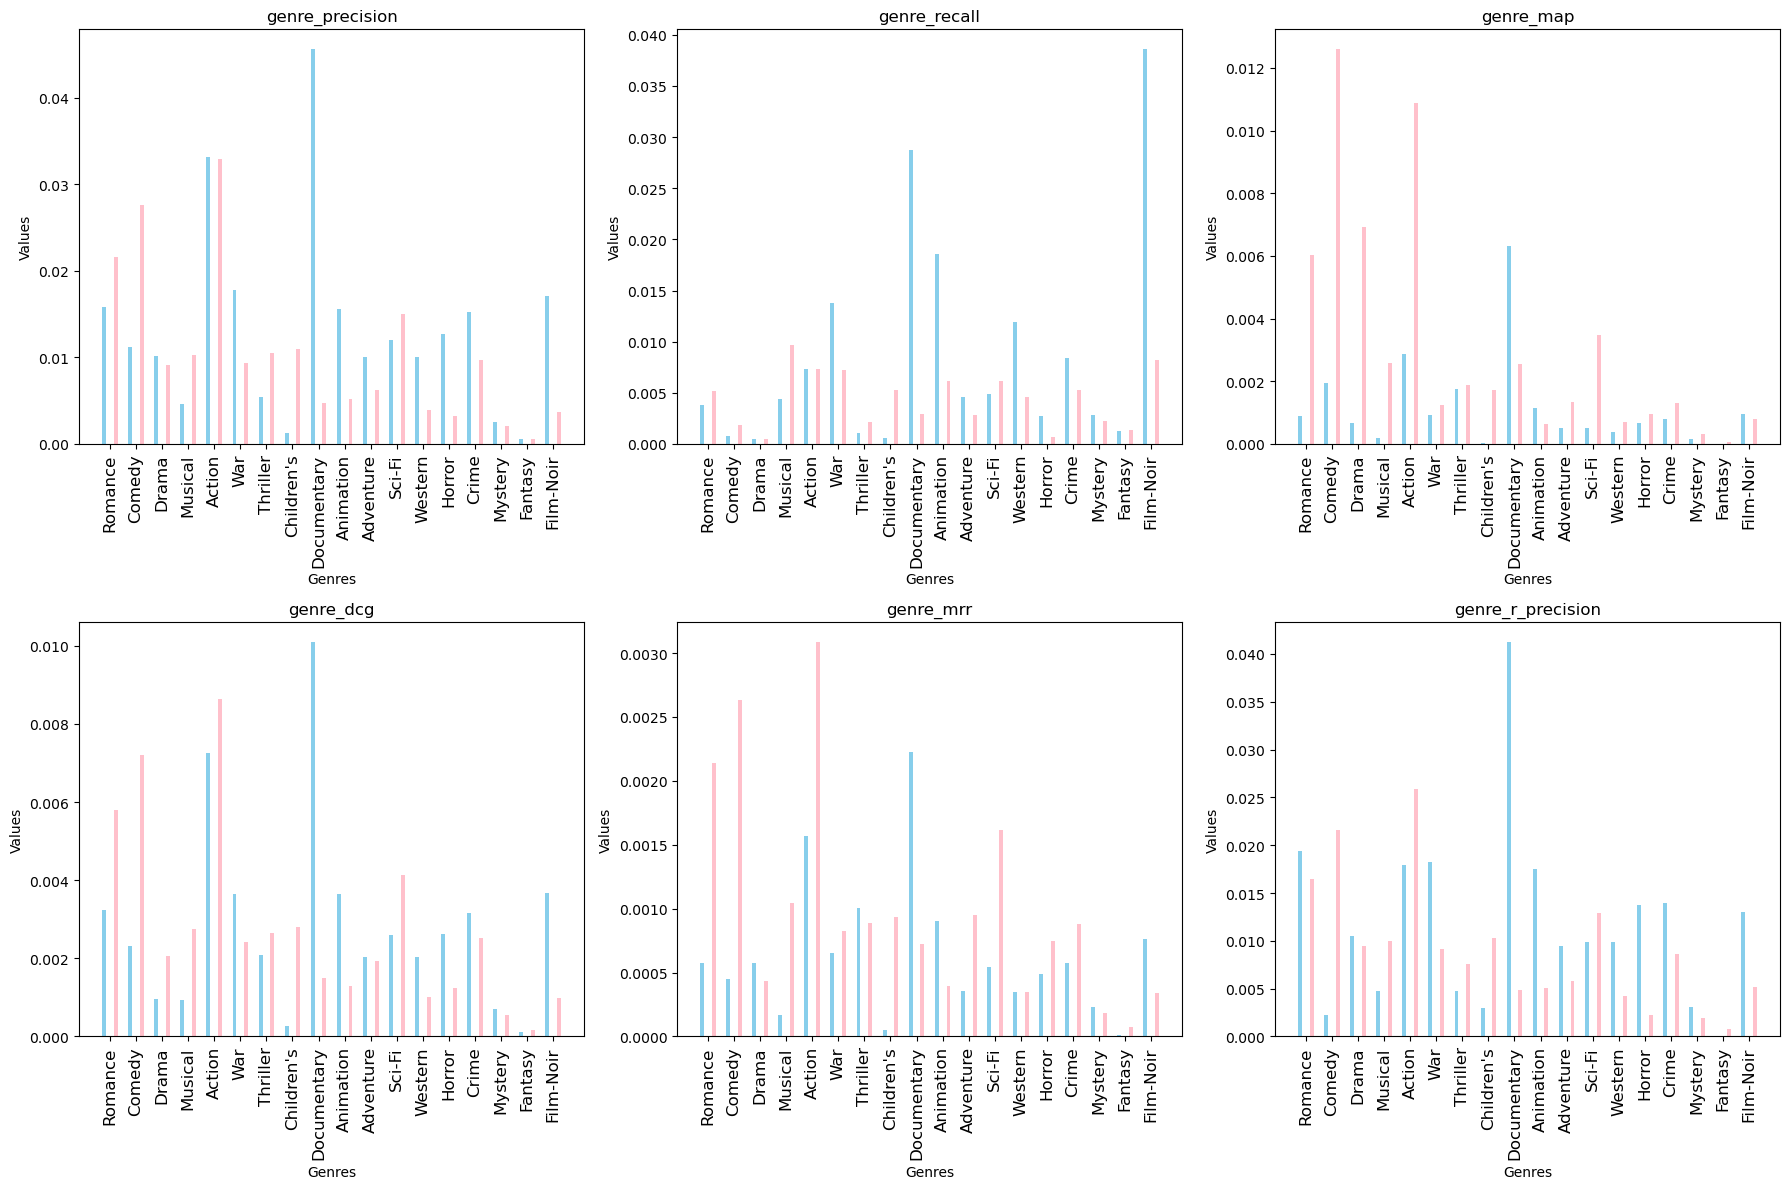

In [119]:
import matplotlib.pyplot as plt
import numpy as np



matrices =[model_gp,model_gr,model_gm,model_gdcg,model_gmrr,model_grp]
matrices_2 =[model_gp_2,model_gr_2,model_gm_2,model_gdcg_2,model_gmrr_2,model_grp_2]
matrices_3 =[model_gp_3,model_gr_3,model_gm_3,model_gdcg_3,model_gmrr_3,model_grp_3]

# values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = [ "genre_precision","genre_recall","genre_map","genre_dcg","genre_mrr","genre_r_precision"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.15  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(x-3*bar_width/2, matrices[i], bar_width,color="skyblue")
    axs[i].bar(x+3*bar_width/2, matrices_2[i], bar_width,color="pink")
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(unique_genres, rotation=90, fontsize=12)
    
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

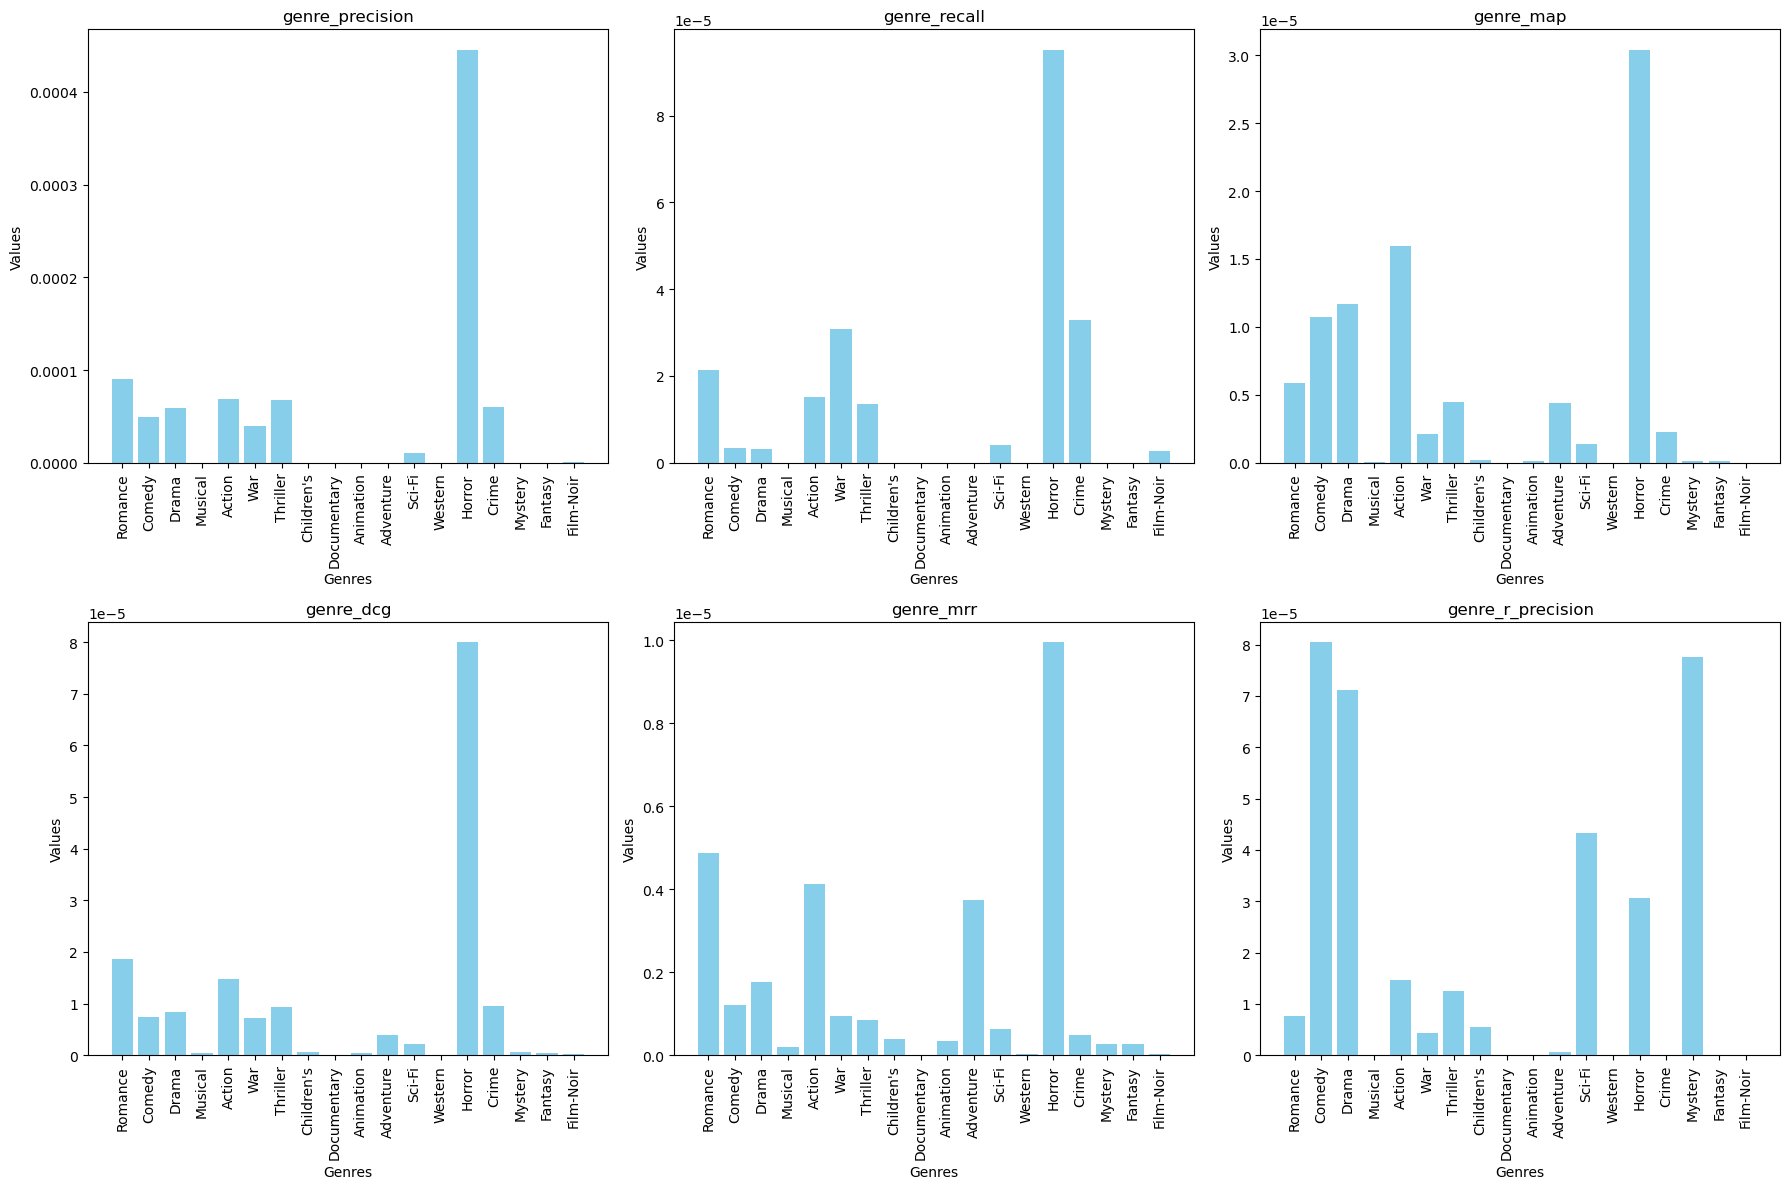

In [70]:
import matplotlib.pyplot as plt
import numpy as np



matrices =[model_gp,model_gr,model_gm,model_gdcg,model_gmrr,model_grp]

# values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = [ "genre_precision","genre_recall","genre_map","genre_dcg","genre_mrr","genre_r_precision"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(titles)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

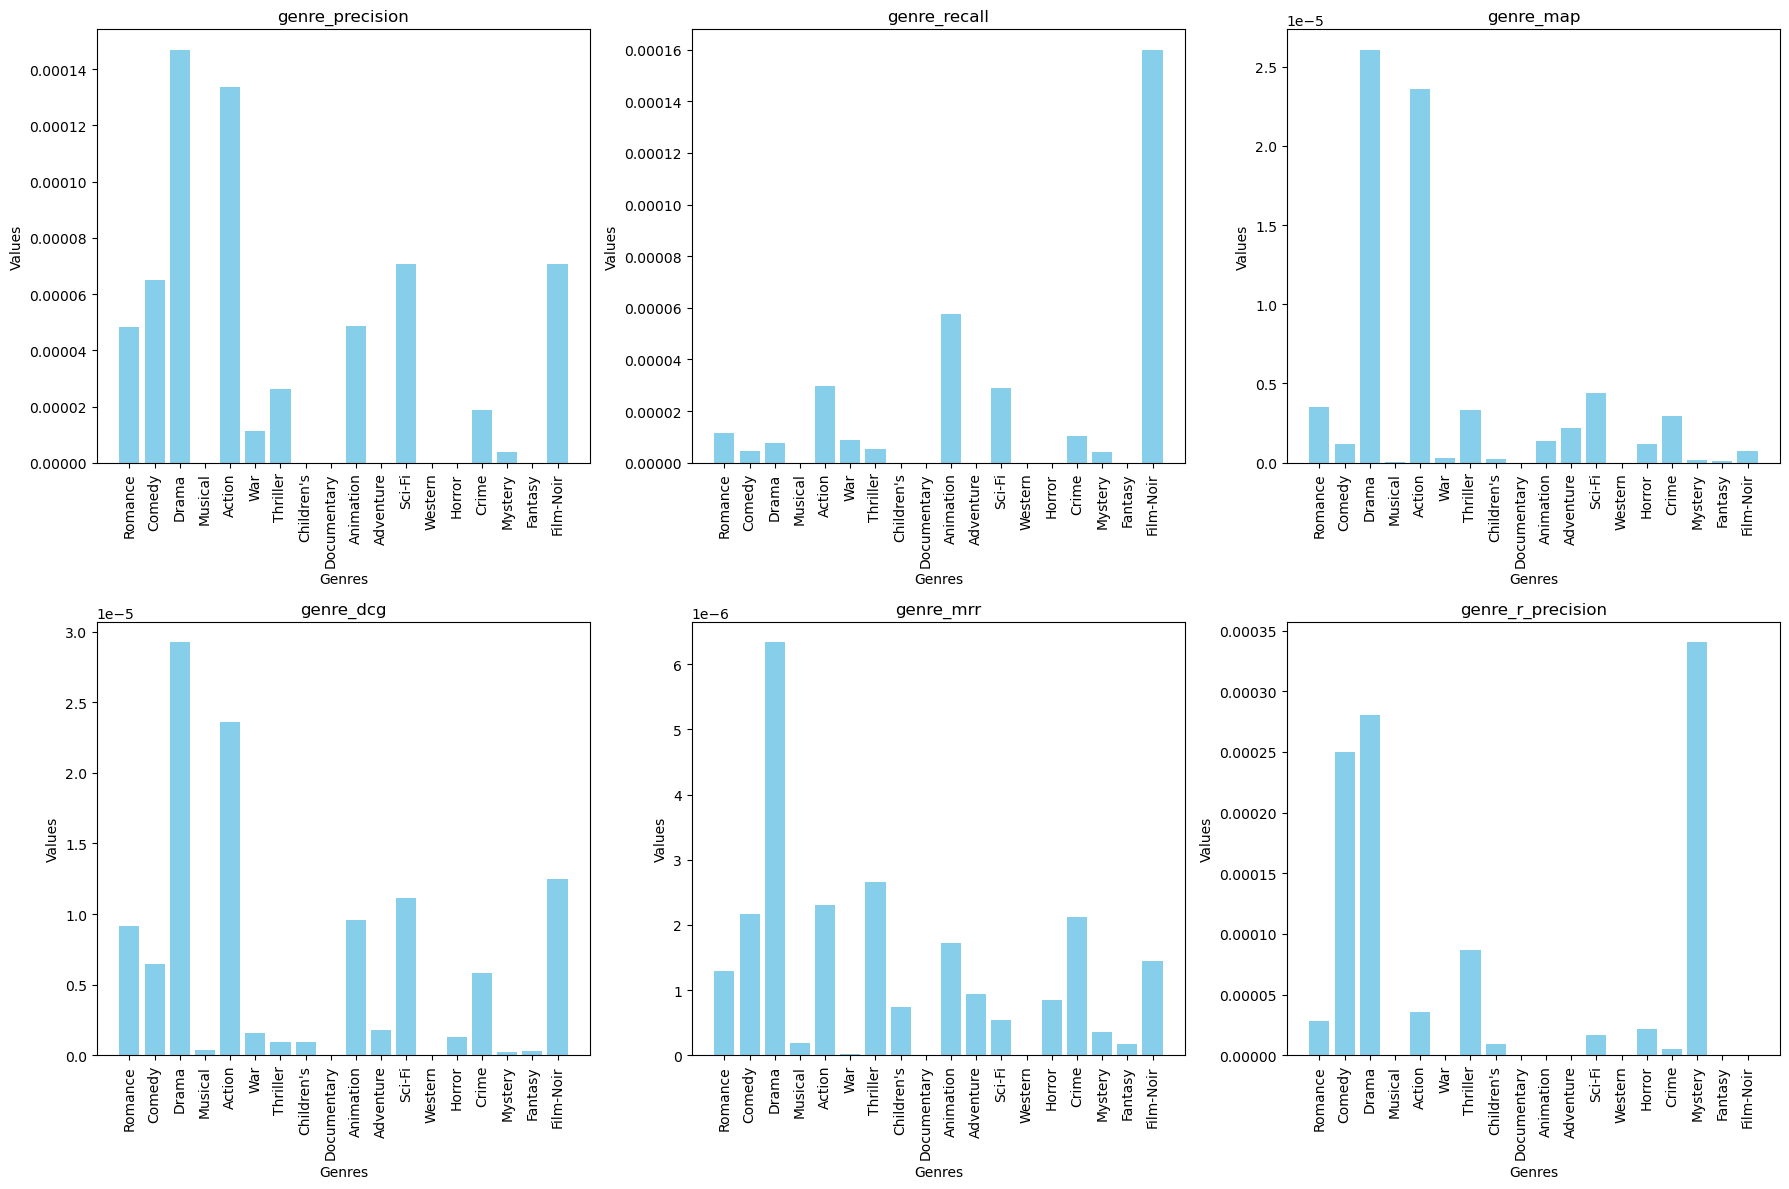

In [80]:
import matplotlib.pyplot as plt
import numpy as np



matrices =[model_gp,model_gr,model_gm,model_gdcg,model_gmrr,model_grp]

# values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = [ "genre_precision","genre_recall","genre_map","genre_dcg","genre_mrr","genre_r_precision"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(titles)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [32]:
reco_matrix_all_items

array([[3414, 3230, 3382, ..., 2834, 3191, 3415],
       [3414, 3230, 3382, ..., 2834, 3191, 3415],
       [3230, 3382,   13, ..., 3191, 2834, 3415],
       ...,
       [3414, 3230, 3382, ..., 2834, 3191, 3415],
       [3414, 3230, 3354, ..., 2834, 3191, 3415],
       [3414, 3230, 3354, ..., 2834, 3191, 3415]])

In [38]:
itemknn = matrices
itemknn

[array([2.52699421e-05, 5.38335919e-04, 4.18371471e-04, 5.02272210e-04,
        3.96816272e-05, 1.97881679e-04, 2.68782664e-04, 7.06700556e-04,
        5.83239289e-05, 3.72770827e-04, 6.69145474e-05, 2.03775522e-04,
        1.88443775e-04, 2.80164631e-04, 1.39942933e-04, 2.46834536e-04,
        1.47538146e-05, 2.89574343e-04]),
 array([5.72149633e-05, 3.64759183e-05, 4.96681604e-04, 2.76125459e-04,
        7.96499944e-06, 2.34642307e-04, 1.28830163e-04, 5.48396707e-04,
        5.51787407e-05, 2.34447061e-04, 7.28123475e-05, 4.53640966e-05,
        4.46549230e-05, 1.15500054e-04, 6.35622707e-05, 1.28394703e-05,
        3.29571437e-05, 6.18704529e-05]),
 array([3.02076309e-06, 7.22572510e-05, 7.04398160e-05, 2.04782267e-05,
        3.20277269e-06, 2.80516375e-05, 2.40028354e-05, 3.25508046e-05,
        4.56744341e-05, 1.38030631e-05, 6.20398007e-06, 1.35226678e-05,
        1.74397456e-05, 2.53655989e-05, 9.45475957e-06, 5.99141770e-04,
        2.20683686e-06, 5.78651323e-06]),
 array([1.

In [ ]:
s=0
for i in range(len(titles)):
    s=sum(MF_0_5[i])+s
print(s)

1.131974830710647e-16


In [33]:

s=0
for i in range(len(titles)):
    print(sum(MF_0[i]))
    s=sum(MF_0[i])+s
print(s)

0.004558794925673907
0.002525518681453498
0.000992603476589191
0.0009499180066664342
0.014391470894008308
0.0028761175084075132
0.026294423492798855


In [6]:
reco_matrix_all_items=np.load('reco_matrix_all_items.npy' )
reco_matrix_all_scores=np.load('reco_matrix_all_scores.npy' )
itemknn=np.load('itemknn.npy' )

#reco_matrix_all_items

In [17]:

top_k = 50
reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
for i in range(reco_matrix_all_items.shape[0]):
    reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [19]:
reco_matrix.shape

(6040, 50)

In [45]:
# tahsin kheya
# last modified 21/05/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger


class Calibration(object):
    def __init__(self, config, movies,top_k,unique_genres,users):
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []
        self.unique_genres=unique_genres
        # self.logger = getLogger()
        self.top_k=top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.config = config
        self.item_df = movies
        self.actual_distribution = self.actual_genre_dist.to_numpy()
        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(
                    np.arange(topk_reco.shape[0]), self.top_k
                ),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(
                    np.arange(1, self.top_k + 1), topk_reco.shape[0]
                ),
            }
        )
        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[
            self.unique_genres
        ].div(merged_df[self.unique_genres].sum(axis=1), axis=0)
        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None]
            * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        reco_distribution[self.unique_genres] = reco_distribution[
            self.unique_genres
        ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):
        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))
        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        # Normalize genre weights so sum is 1
        item_genre_weights /= np.sum(item_genre_weights, axis=1, keepdims=True)
        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)
        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    def get_gender_representation_one_user(self, reco_dist, uid):
        c = []
        retVal = []
        print(self.actual_distribution[uid])

        for i in range(len(self.unique_genres)):
            c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
        # Assuming self.unique_genres is a list or array-like
        genre_columns_count = len(self.unique_genres)

        # Slice the necessary parts of reco_dist and actual_distribution
        reco_dist_slice = reco_dist[:genre_columns_count]
        actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

        # Compute the logarithms of the ratio
        log_ratios = np.log(reco_dist_slice / actual_dist_slice)

        # Convert log_ratios to a list and append to retVal
        retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
# 
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])

        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution[uid][1:], alpha, uid
        )
        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids=self.gender_df[self.gender_df["Gender"]==0]["userID"]
        male_user_ids=male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[uid][reco_items[r]]

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl
# c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items,items, scores):
        
        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(reco=top_items, scores=scores, all_items=items)

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(self.actual_genre_dist, self.gender_df, on="userID")
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores,all_items):
        """reco is 6040x50 and scores is 6040x3416"""
        

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        l = 0.69  # lambda
        b = 0.29  # beta
        all_users = []
        # male_active_users= [4168,1679,4276]
        male_active_users = [4168]
        female_active_users = [1149]
        # female_active_users= [1149,1087,3223]
        male_inactive_users = [1712]
        # male_inactive_users= [1712,4067,2713]
        female_inactive_users = [2583]
        # female_inactive_users= [2583,2159,97]
        test_users = (
            male_active_users
            + female_active_users
            + male_inactive_users
            + female_inactive_users
        )
        top_k = self.top_k

        n_users, n_items = scores.shape

        for u in range(n_users):
            remaining_items = list(range(n_items))
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores, user_reco_dist, b
                    )
                    for i in remaining_items
                ]

                max_index = np.argmax(diversity_scores)
                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)


In [46]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file":"./cornac/data_c/user_genre_dist.csv"}
c=Calibration(config=config, movies=movies,top_k=50, unique_genres=unique_genres, users=users)
c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores)

[474]
[474, 1575]
[474, 1575, 1000]
[474, 1575, 1000, 1120]
[474, 1575, 1000, 1120, 121]
[474, 1575, 1000, 1120, 121, 13]
[474, 1575, 1000, 1120, 121, 13, 1]
[474, 1575, 1000, 1120, 121, 13, 1, 3414]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20, 441]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20, 441, 396]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20, 441, 396, 2646]
[474, 1575, 1000, 1120, 121, 13

KeyboardInterrupt: 

In [47]:
pip show cornac

Name: cornac
Version: 2.2.1
Summary: A Comparative Framework for Multimodal Recommender Systems
Home-page: https://cornac.preferred.ai
Author: 
Author-email: 
License: 
Location: /Users/tahsinalamgirkheya/Desktop/work/cornac-master
Editable project location: /Users/tahsinalamgirkheya/Desktop/work/cornac-master
Requires: numpy, powerlaw, scipy, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)
    
    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if (movies.at[index,genre]==1):
                movies.at[index, genre] = weight_per_genre

In [25]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd,movies, how="inner",on="itemID")
mergde_pd

,userID,itemID,Rating,Timestamp,movieID,genres,Romance,Comedy,Drama,Musical,...,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
0,0,0,5,978300760,1193,Drama,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,3,978302109,661,Animation|Children's|Musical,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,0,2,3,978301968,914,Musical|Romance,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,3,4,978300275,3408,Drama,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999606,6039,772,1,956716541,1091,Comedy,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
999607,6039,1106,5,956704887,1094,Drama|Romance|War,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
999608,6039,365,5,956704746,562,Comedy|Drama,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
999609,6039,152,4,956715648,1096,Drama,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
user_genre_means = mergde_pd.groupby('userID')[unique_genres].mean()
user_genre_means


,Romance,Comedy,Drama,Musical,Action,War,Thriller,Children's,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
userID,,,,,,,,,,,,,,,,,,
0,0.113208,0.264151,0.396226,0.264151,0.094340,0.037736,0.056604,0.377358,0.000000,0.339623,0.094340,0.056604,0.000000,0.000000,0.037736,0.000000,0.056604,0.000000
1,0.186047,0.193798,0.612403,0.000000,0.434109,0.116279,0.240310,0.000000,0.000000,0.000000,0.147287,0.131783,0.023256,0.015504,0.093023,0.023256,0.007752,0.007752
2,0.098039,0.588235,0.156863,0.019608,0.450980,0.039216,0.098039,0.058824,0.000000,0.058824,0.490196,0.117647,0.117647,0.058824,0.000000,0.019608,0.039216,0.000000
3,0.095238,0.000000,0.285714,0.000000,0.904762,0.142857,0.190476,0.047619,0.000000,0.000000,0.285714,0.428571,0.095238,0.142857,0.047619,0.000000,0.095238,0.000000
4,0.151515,0.282828,0.525253,0.015152,0.156566,0.030303,0.196970,0.030303,0.030303,0.020202,0.045455,0.075758,0.005051,0.050505,0.106061,0.040404,0.000000,0.015152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6035,0.137387,0.293919,0.418919,0.034910,0.173423,0.047297,0.165541,0.060811,0.012387,0.038288,0.093468,0.190315,0.015766,0.083333,0.059685,0.038288,0.021396,0.019144
6036,0.108911,0.292079,0.485149,0.019802,0.138614,0.079208,0.336634,0.029703,0.004950,0.004950,0.044554,0.193069,0.019802,0.044554,0.089109,0.064356,0.019802,0.044554
6037,0.300000,0.600000,0.450000,0.000000,0.100000,0.200000,0.000000,0.050000,0.000000,0.150000,0.050000,0.050000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000


In [ ]:
users

In [23]:
useer= pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby('Gender')[unique_genres].mean()
user_genre_gender


,Romance,Comedy,Drama,Musical,Action,War,Thriller,Children's,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
Gender,,,,,,,,,,,,,,,,,,
0,0.122910,0.333905,0.349891,0.033846,0.293061,0.083442,0.205927,0.063334,0.007557,0.042885,0.146342,0.189403,0.022248,0.077736,0.084999,0.04086,0.037210,0.023263
1,0.209183,0.385891,0.405863,0.054968,0.186861,0.066352,0.167682,0.086136,0.008390,0.053312,0.110675,0.113051,0.012789,0.056306,0.068770,0.04206,0.035231,0.020935


In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z= inter_movies[["userID","itemID","Gender"]]
mergz= pd.merge(z,movies, on="itemID",how="left")
mergz
user_genre_gender = mergz.groupby('Gender')[unique_genres].mean()
user_genre_gender


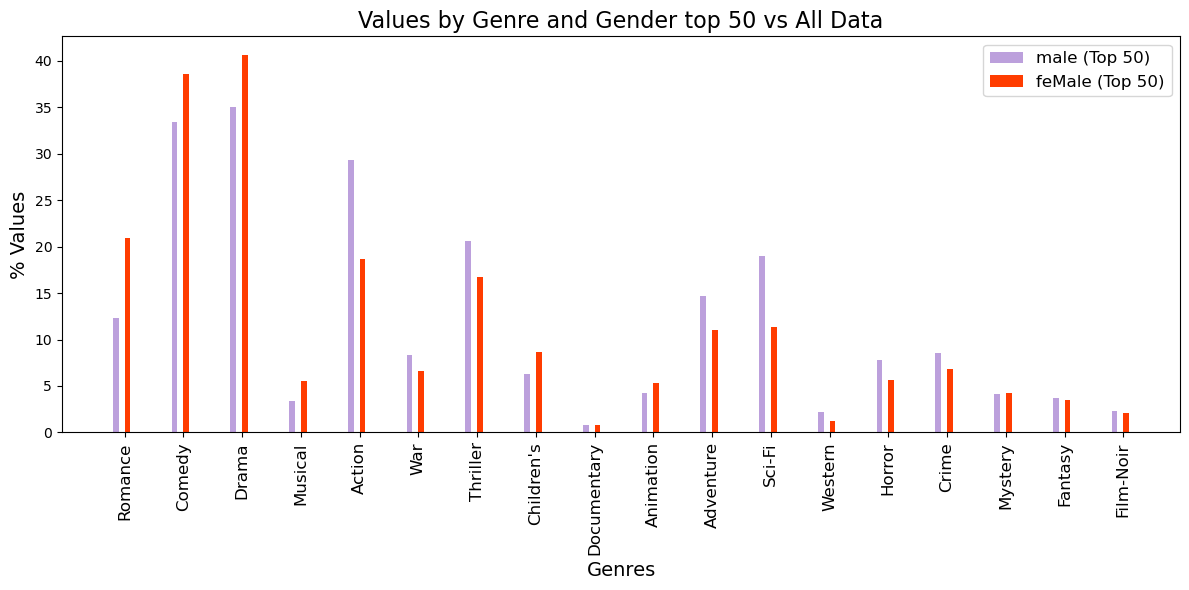

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='feMale (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='female (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [35]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

(6040, 50)

In [37]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


,Romance,Comedy,Drama,Musical,Action,War,Thriller,Children's,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
Gender,,,,,,,,,,,,,,,,,,
0,0.058084,0.245154,0.575216,0.015225,0.126931,0.077345,0.147407,0.018375,0.056421,0.051180,0.065574,0.050187,0.012307,0.024909,0.061575,0.043214,0.008455,0.041081
1,0.058419,0.244543,0.574309,0.015340,0.126358,0.075808,0.147307,0.020035,0.056440,0.053899,0.065539,0.049274,0.012213,0.024344,0.060937,0.042506,0.009028,0.040913


In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame


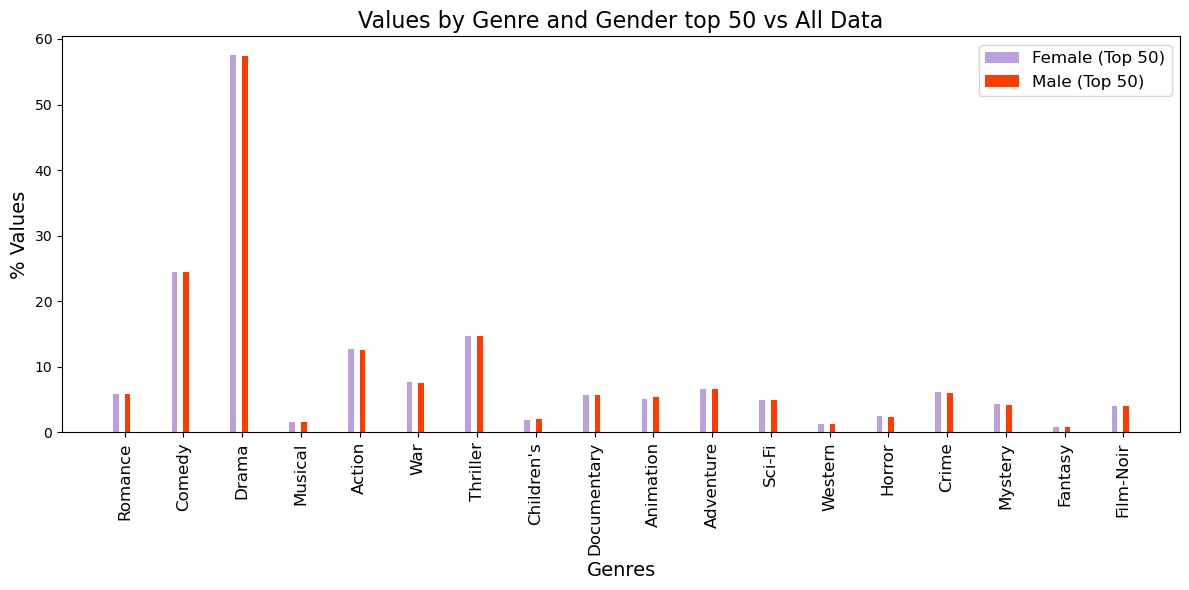

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix.shape[0] + 1).repeat(reco_matrix.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv('biased_movie_lens.csv')

In [81]:
movies_df

Romance        211.000000
Comedy         737.933333
Drama          961.233333
Musical         52.850000
Action         224.600000
War             64.433333
Thriller       249.100000
Children's     104.316667
Documentary     79.500000
Animation       42.116667
Adventure      110.083333
Sci-Fi         121.283333
Western         42.166667
Horror         234.016667
Crime           90.950000
Mystery         45.950000
Fantasy         22.383333
Film-Noir       22.083333
dtype: float64

In [120]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)

In [122]:
a=[-1.4866574637196672, -1.7382438913148257, -1.6021411436415565, -1.4707782400311613, -1.4551384013847226, -0.9868468036389964, -1.1561819085843785, -1.1498527863125871, -1.7402270694895148, -1.2837982034441797, -1.7662277709343952, -1.8055325784401637, -1.4988066660879231, -1.4796031210436662, -1.8422903517751488, -1.4507471944279453, -1.7834574761619155, -1.813403487505823, -1.473792304957517, -1.4473474451795518, -1.4636390264214665, -1.8673345463228785, -1.2660667878272738, -1.446579737860858, -1.6740029708883164, -1.5552633276234664, -1.2612346850446023, -1.3074391691115623, -1.4890502704274438, -1.1589271452153054, -1.7894407105372865, -1.4817291386522786, -1.2515210706533466, -1.4141907911374023, -1.8034173269685885, -1.7272158351202047, -1.4867801728901888, -1.7666575420647646, -1.4875477060525848, -1.4717791565436624, -1.4361519748313696, -1.4687522498632823, -1.4877827528869243, -1.4094360967498574, -1.2738617776981198, -1.4378533669818538, -1.7421950731728424, -1.490391156619902, -1.2469325287622073, -1.4883117266596873, -1.436108082996371, -1.1378548886905737, -1.4747387417488305, -1.3204966686660027, -1.4737856742807398, -1.4475941491606616, -1.4217164641561286, -1.27990862602033, -1.449849757230357, -1.4424507432280127, -1.2599126897596298, -1.4657630117043092, -0.9872943531178036, -1.4917803964921994, -1.0475954545247528, -1.3031203531435376, -1.3016461134871848, -1.4694064565014648, -1.301246864844714, -1.3036769738947287, -1.1023807255943443, -1.4186459273226122, -1.4190028806146, -1.2677762044267358, -1.305234278809078, -1.005096395583791, -1.0985012319335798, -1.3027030174573786, -1.3017123804039858, -1.0202424024098928, -1.4787339937436954, -1.4837729602430705, -1.3216248021668726, -1.2105801968638357, -1.017704863132975, -1.1708498121733653, -0.9899003487255018, -1.4957659628626567, -1.2938779198173527, -1.1368497830775017, -1.3036922249913032, -0.8645748703363223, -1.2419186944249876, -1.2840362516989472, -1.2976538281636527, -1.1580075380314623, -1.2777244438278619, -1.1154413344881071, -1.3413596985922815, -1.2399436201839493, -1.4777993281202295, -1.464551860348602, -1.4788257645546012, -1.4876984026684608, -1.156842086588706, -1.484792304952017, -1.4857618179533547, -1.4173706308555991, -1.4747797305682935, -1.3154931509252523, -1.3755047702579697, -1.439403377086086, -0.9935719986139544, -1.2845315050141601, -1.476749058257057, -1.2682989497899573, -1.3129338909901027, -1.3016991382869532, -1.1425699530868454, -1.2664660738206623, -1.2997175498273836, -1.1459240283140377, -1.2559296684508867, -1.263691118808676, -0.9205750650328987, -1.1574110611756077, -0.9891262553985679, -1.4670698903516184, -1.1721069395825878, -1.4456556778993912, -1.2956711702127552, -1.3816545148724828, -1.1235514387130738, -0.9991887957193273, -1.2868528950881255, -1.4594375316692008, -0.9821208932035751, -1.1713644220792978, -1.449713903373005, -1.3062564278364142, -1.4939437981814436, -1.145859937901793, -1.5037570172341281, -1.467497284793097, -1.1447395339304263, -0.9887443048163848, -1.3017159134774938, -1.431733480311674, -0.9817031992515859, -1.49584531541809, -1.183602902615363, -1.3036521175599531, -1.4727946595918, -1.2538830174539553, -1.631193977156746, -1.431417855630234, -1.2952039272755154, -1.6618093680420116, -1.1479535077174035, -1.4837519829665504, -1.347273649296822, -1.2995416833868347, -1.4728223781823857, -0.9658275427329028, -1.1318579551149506, -1.3184837534758636, -1.3036794881194087, -1.5019589876011166, -1.160951524175171, -1.5048190543228697, -0.9981452133688006, -1.2320198260047024, -1.4817839120139, -1.141422335099875, -1.3114830919502216, -1.4536414406183655, -1.4586974831746116, -1.4757388030739653, -1.4497141898782104, -1.442697117272606, -1.1400240764659368, -1.2705077796971849, -1.442688367967709, -1.4515918743465697, -1.4577231371867243, -1.322761615339102, -1.4671050567124413, -1.4388712247655104, -1.3721934482906892, -0.9774991203192378, -1.4587690960773945, -1.4590298949433282, -1.090140198035008, -1.1419220908589682, -1.769796548383606, -1.1563895019258958, -1.2245732308894566, -1.2175739045966334, -1.4567140492331858, -1.2245551072244938, -1.3177452343186373, -1.3503788766655276, -1.1044829743312992, -1.3926926542383053, -1.3177354418918203, -1.461985674258677, -1.4706996929838727, -1.2384480399848359, -1.5860050395365892, -1.07957458391626, -1.317787898337202, -1.418415535726495, -1.4092041947958927, -1.5409377250531435, -1.1144943788513382, -1.5550427314770607, -1.6501341609529199, -1.1205632724989196, -1.6246355713686447, -1.5047153113732943, -1.2749924251936808, -1.3038561247878988, -1.3186015310377268, -1.5009083650330748, -1.3175231003206185, -1.1429458059675193, -1.4433645053977933, -1.4441848995128899, -1.0145622670992935, -0.9936570937225151, -1.6509391625628242, -1.4606573611065987, -1.30748852326349, -1.4777942119520366, -1.4785503213653977, -1.4807996467176148, -1.421556951827632, -1.4164183228251943, -1.3193995990719414, -1.4328120346407027, -1.2976442981231218, -1.7824192967273331, -1.4478569306102818, -1.4580542686920768, -1.4504025231674516, -1.8553006346018686, -1.438616566451095, -1.4456788144547452, -1.4878133362574513, -1.4828044057457825, -1.3993080043195862, -1.2860099833217464, -1.0149499513255287, -1.4705382341965603, -1.1539678297235576, -1.2979661942433274, -1.4757923049565171, -1.3125144870818612, -1.4823845471396777, -1.450890231163357, -1.4506827839775511, -1.8553162740082816, -1.8613180214781582, -1.5522628090097828, -1.1357549252230768, -1.4767789642519717, -1.1429377759349704, -1.15298431704894, -1.537385238604427, -1.1692798275642584, -1.4949053736776285, -1.3085271531232645, -1.4243435089820777, -1.416358471079495, -1.478729093015628, -1.1508905874826891, -1.860270947037024, -1.004974364864583, -1.7592471251682302, -1.482833130889686, -1.4775476603700415, -1.4697353275707656, -1.5027919615101444, -1.3084548545984651, -1.4797923049545172, -1.1329195369443223, -1.6409302924748788, -1.1329505767724317, -1.282106633405622, -1.4776873294141468, -1.4638248350050502, -1.8113517045352625, -1.4813431001415318, -1.5840859358804316, -1.5313852955952068, -1.4858527344777959, -1.3093049721578294, -1.3313409875929767, -1.4637017969887247, -1.311515796246069, -1.6331613147706832, -1.701201050364945, -1.488528138021839, -1.308466818085412, -1.4745418958488974, -1.1757233626672479, -1.4847593273853332, -1.1523142854070354, -1.474832403331049, -1.875235707123954, -1.479785724662031, -1.4550294001633004, -1.4797998801018046, -1.4588254119514235, -1.1539288650649788, -1.4436935640375355, -1.454457188596523, -1.470797751388097, -1.48277432280039, -1.132789265124989, -1.474773136754426, -1.1580197370061678, -1.0133197232437499, -1.4746745636513243, -1.4420545634706605, -1.418769245683547, -1.4177699494609095, -1.301679551405078, -1.162980605956295, -1.2868012873281778, -1.4857914730429143, -1.4298812059961505, -1.4487023367052723, -1.3137976409074463, -1.442692046179959, -1.4494157405136905, -1.4498583116515236, -1.5062679562257741, -1.791575084207502, -1.4788138229660244, -1.1569841784212886, -1.4711631138080734, -1.4717123785584723, -1.1282956573526677, -1.3315797172678199, -1.4516974119549957, -1.1597871108521574, -0.9707235883658356, -1.296363748551348, -1.6617751550978745, -1.4486513536509307, -1.479782095482196, -1.4396866511096726, -1.4637748916934301, -1.4526531021206521, -1.4797769210598388, -1.1458667660203052, -1.153837362688213, -1.4727823594366884, -1.2826589998037952, -1.4787881156043063, -1.47270899932368, -1.8763672823691016, -1.4741540621703255, -1.444411993653926, -1.1429435408940436, -1.4768253088234298, -1.4945754065340504, -1.4687355318364073, -1.2869191002479132, -1.3285854614835904, -1.1329073329979669, -1.4747021597127548, -1.4677136696433244, -1.7644431782955736, -1.1477062102728635, -1.307785531157467, -1.1359297302658988, -1.31449776841548, -1.461669623362035, -1.4536624136339884, -1.144880272259134, -1.2867447204162912, -1.4927870682274147, -1.764788590094993, -1.0058891604066122, -1.4502313509959766, -1.5851487251367897, -1.5913198020751804, -1.7351865971238727, -1.730209075734648, -1.2888606215067078, -1.4546983835279619, -1.7646022660182639, -1.7698031712926348, -1.3154598142049845, -1.3058553157313633, -1.753816916870949, -0.9901488743557495, -1.3119406895951826, -1.3179193087951973, -1.4697394461688846, -1.4335797846438432, -1.8295325784281635, -1.1357284876906837, -1.2894074976170218, -1.239894099716869, -1.7698494990857054, -1.7358630206048553, -1.0001337868359903, -1.8175081631291243, -1.3155858812295078, -1.0011342696206151, -1.3838310780981569, -1.6072795705023761, -1.475781098763991, -1.2074515237979357, -1.3294781838445113, -1.2978686620811728, -1.6151653619186797, -1.2592809562853384, -1.4820808852179432, -1.3082311771089086, -1.2988897062490286, -1.287893753697824, -1.3125478091868, -1.2748799746593553, -1.4536427179142184, -1.0125014862965969, -1.1559358573484158, -1.326868469463957, -1.7572439970855487, -1.1209090105870905, -1.3137108747834687, -1.3027186431307443, -1.4738035160555016, -1.4737898701858447, -1.3265328325709338, -1.4757796802355467, -1.4807721111285994, -1.7804392497493828, -1.2809185645959675, -1.4848478105131042, -1.138886012802148, -1.4828011537756247, -1.4698128763907163, -1.1358438214192021, -1.500729481975457, -1.246270621718392, -1.4746955339536125, -1.14002158331744, -1.474767562517193, -1.3140020181472656, -1.3105181375827104, -1.4737250659584173, -1.3164113490778928, -1.4754864955581493, -0.9807569017684029, -0.960405255834591, -1.1649791918953034, -1.4787923049550171, -1.132981430471118, -1.471793890576036, -1.4835989427421512, -1.3344082930072143, -1.1630046014306805, -1.1528054307733124, -1.1629611717910058, -1.6078492929066992, -1.167505095887512, -1.3105093969859523, -1.3144375561948276, -1.3085293253840136, -1.2429157522356427, -1.1253896518595075, -1.484747153861937, -1.6291526114860793, -1.4827947462945361, -1.4752927881564708, -1.48070309991953, -1.4777948378717958, -1.3255908679233173, -1.4232439802228898, -1.4828940903899346, -1.5065996969510014, -1.13993498034754, -1.166014810268137, -1.302492079748374, -1.4353823076948378, -1.2788626095913145, -1.4778356295248, -1.4867720416867138, -1.472228361927731, -1.1432876548926638, -1.5059377366746387, -1.39348008933554, -1.4918576207714151, -1.590139083835773, -1.302484527703745, -1.4490199421559495, -1.472323325413864, -1.1900316279835335, -1.1418915739849274, -1.159977311952254, -1.3123112581316512, -1.1329297492706492, -1.5081659570273065, -1.5018556548286446, -1.49081007665288, -1.4787937908203406, -1.4972371226436998, -1.4957600860288183, -0.8342368951259289, -1.470764312753435, -1.4261886391298364, -1.4466706063061037, -1.4949024918246632, -1.4476967331547788, -1.4807433435630808, -1.194995561024903, -1.4746917966623032, -1.2928814324208895, -1.4307655352600683, -1.4836062543066912, -1.5016430678221089, -1.475707269604026, -1.4342360304488266, -1.1697772031910199, -1.2874722585564462, -1.1904093944518692, -1.4717903099693923, -1.4361442855988864, -1.2193500783009419, -1.149364833384129, -1.4566955481833768, -1.4620885930543022, -1.340513959313462, -1.4497229048718134, -1.2876447241235587, -1.4760805716745202, -1.4427003624564725, -1.3164593029189562, -1.4828294723634314, -1.6739954179147718, -1.4823569748539303, -1.4727857270957578, -1.2549371293210876, -1.2868695066951552, -1.4737791074499147, -1.8601556982178562, -1.4847811624419567, -1.4492491576999476, -1.302894262044647, -1.507070163175682, -1.777237721709299, -1.0776329908744895, -1.4435473024314687, -1.313513959326962, -1.1210761967902445, -1.47321331578955, -1.683138661687735, -1.4596900486006008, -1.397083445086065, -1.4606961527701119, -1.1285496259560883, -1.1685082117216752, -1.4486120941151637, -0.9925274650844538, -1.5812163319346535, -1.5892266777795734, -1.4888261863842245, -1.2848709151572502, -1.6409637675217792, -1.6160988037495247, -1.2800529429051406, -1.119264110794388, -1.2898852100334532, -1.298723622609281, -1.6277377055183297, -1.4517258207906407, -1.801469759292292, -1.322520907983831, -1.4367478725751832, -1.2866965814996068, -1.5532725093858881, -1.1555161226298465, -1.2986847492175735, -1.1475317096208277, -1.8114529057828168, -1.4957687927858914, -0.9728832043428562, -1.5693364349116155, -1.4546596586788991, -1.4958347970032206, -1.7512594432974373, -1.63510390942788, -1.4053135925649198, -1.1378043671389746, -1.4547048408945265, -1.2730440052354286, -1.4006518716378815, -1.4695908946970775, -1.7655596022575475, -1.2081358202906498, -1.4416961998509805, -1.2764090208429424, -1.4238126856695408, -1.4803669455792903, -1.2625475105549901, -1.724220779964068, -1.7688328380333862, -1.5426235999012867, -1.6954315869751109, -1.3390069807180152, -1.4406764036486719, -1.3794077625218906, -1.457440852653057, -1.4375098030416966, -1.4535836265983764, -1.2839997159923346, -1.7904186665513369, -1.4516505076026531, -1.6201290453096209, -1.0953032133127103, -1.806483263463408, -1.4446664646964278, -1.584411664601344, -1.4396400305582076, -1.4063831437627965, -1.4757204064833052, -1.273420542391887, -1.4496251583721544, -1.7281999081174133, -1.3920955897321494, -1.1559692684504705, -1.3504379000781137, -1.6001577599381864, -1.4366868516179225, -1.4677827552317955, -1.284846570068295, -1.3194850040363384, -1.2664257745103493, -1.4573025541337554, -1.2694849972479145, -1.2664287783087966, -1.2973732799969406, -1.267412463934535, -1.1233767393727048, -1.303818133313631, -1.8235383960507687, -1.5013503533450687, -1.2272885558068989, -1.442695801377593, -1.6619995173523574, -1.4697309655909274, -1.413820138115303, -1.628781155456969, -1.451677043143784, -1.445239207830589, -1.149923644274648, -1.475803967671768, -1.5017454437344737, -1.0090214252857046, -1.2709101289283284, -1.4334258149580228, -1.4887509554744423, -1.4284314643780447, -1.473710779831312, -1.4546907129439264, -1.2738552531597538, -1.8235168290256993, -1.7804149021871594, -1.877263808666406, -1.6061666937847554, -1.004171932528541, -0.9788676712661154, -1.2590428645344636, -1.766586494549925, -1.4790338399486265, -1.6489594201582838, -1.6023465772355143, -1.4778094704646745, -1.7432117558960842, -1.26811822787212, -1.3085324237321374, -1.4697631539188039, -1.4796106325977507, -1.4475642985123507, -1.4517392635364441, -1.4448498901882878, -1.290866888681161, -1.4426667517811915, -1.4576955481828766, -1.4878054535904988, -1.4867905817860818, -1.1468806856651057, -1.4403130431240911, -1.417377847819705, -1.463663176155815, -1.443629853936326, -1.3004889807745033, -1.4667168310684793, -0.9809094548399822, -1.1437433020953642, -1.475788843615246, -1.482332726485136, -1.5096485170660616, -1.4657096163256278, -1.285843019177582, -1.2898655227178095, -1.4747328955336998, -0.9638287167868752, -1.830773309566302, -0.9778441146180901, -1.0828221336856683, -1.3875877630892541, -1.4917619818668015, -1.6249318713955434, -1.5925524010442342, -1.2426485023020124, -1.1414873856235812, -1.8405468992889948, -1.433536914651846, -1.2759035957584552, -1.2800975171496358, -1.4395925405111232, -1.6030947037295322, -1.4666917893933786, -1.6331872494090345, -1.2999445625366144, -1.459633264199478, -1.4227722366133113, -1.1319317111406633, -1.1320517536850843, -1.4737646589919655, -1.451737063614921, -1.4756721160099948, -1.2640120837381243, -1.2046056981342779, -1.4369234108641864, -0.8910345361450817, -1.2719207002161717, -1.44988503231685, -1.5958525869314744, -1.4597840416251513, -0.9863619406950799, -1.4387088719521985, -1.5050582656773588, -1.4513322012857612, -1.4550442633759366, -1.792708946329324, -1.4576831043182898, -1.8603099798986167, -1.24889232088187, -1.603913069346902, -1.2606557440254487, -1.4467454189502078, -1.1895527591626203, -1.4309586373924934, -1.4518841741278086, -1.3866642812780223, -1.4678042913538072, -1.4324092488962843, -1.487796852486355, -1.6152058002968652, -1.466763504880902, -1.3077202624153943, -1.2488017098661577, -1.7985218687523865, -1.278871653249225, -1.4329072173211135, -1.4685484782883025, -1.4586931236030103, -1.4898230018398073, -1.4496656931588177, -1.2004428677780485, -1.4539799081822837, -1.4386760664977902, -1.4426424663872843, -1.1260965171549322, -1.4056912581281085, -1.6041541222079243, -1.150878292968977, -1.4187154456474929, -1.8283100846731517, -1.4463998755090928, -1.4516771907040709, -1.454683105829734, -1.4476955481878766, -1.4737861802901686, -1.7582567835754759, -1.4586371392749917, -1.1023702295190267, -1.446620993013164, -1.4822353700799877, -1.859292989118389, -1.3134713809912033, -1.1294090850268708, -1.4376639442037216, -1.4894427151546443, -1.4706673871579232, -1.4476736380729418, -1.3064615657444083, -1.2858191801198906, -1.3146634404360096, -1.4798308026771754, -1.1680359094409607, -1.4698681305871668, -1.1117694481021716, -1.1647839274449687, -1.4647605822800607, -1.472708005262254, -1.453738789611064, -1.453345670512515, -1.2848766947461763, -1.4490138311073029, -1.4807913845331153, -1.4727867034394442, -1.3193616084887678, -1.4467232452274903, -1.8713358603436605, -1.3255187880234505, -1.4697912847608545, -1.6517938762410211, -1.1850481935753516, -1.4646281324488484, -1.4446667013274985, -1.40870664463597, -1.2899266824661253, -1.1134173586229423, -1.480741805640423, -1.141863244849344, -1.4557113495245657, -1.6474605681960717, -1.6910295269035764, -1.805304745922672, -1.6012355207692606, -1.3915434624533316, -1.755252003378212, -1.5944848386258414, -1.2604770453048249, -1.666947071419835, -1.4692795428825047, -1.159394858878798, -1.4761930769353426, -1.6051791428687547, -1.64206781875308, -1.1190009214848797, -1.4758069073888902, -1.143679525397275, -1.2987338707166467, -1.317499752554536, -1.6201761181949128, -1.4643673743459082, -1.186449363051247, -1.5011798205796505, -1.2834846693725535, -1.467043849692087, -1.2788193882474523, -1.1350755921307056, -1.6314866310820886, -1.4176226513731673, -1.2828599176502118, -1.482751986819732, -1.2661159345480815, -1.0121452133618005, -1.4546825106981929, -1.3144677970652174, -1.7713176256128575, -1.415467216792532, -1.293020652231016, -1.4595656347631838, -1.488665553772298, -1.470546954132458, -1.4556870216521243, -1.2828544060794749, -1.479466934905208, -1.4185830334931253, -1.2635198967541135, -1.1470578710152874, -1.2868221741443282, -1.2778648210322714, -1.4623140913408257, -1.468757588058962, -1.0251560979776209, -1.1058749114750406, -1.4838140245395626, -1.1544969659733186, -1.430765289690995, -1.1559727684001386, -1.4759520274774447, -1.3117201286345301, -1.1469335962076719, -1.1398058564130036, -1.5058736442698661, -1.2906555293510915, -1.2649336948917027, -1.5047702295605743, -1.4815497418626669, -1.4456974222054146, -1.4486642396770897, -1.4806683860018912, -1.4667892230630981, -1.2973078624818286, -1.4337109870423452, -1.479407256617888, -1.4581786650774649, -1.4507251108396615, -1.4747161785301968, -0.9265009131869137, -1.4166560306793465, -1.3597568017352268, -1.5067552111593585, -1.4558273985438976, -1.3799250312448046, -1.1519282339793637, -1.7928564370916333, -1.1669546487090445, -0.9961452133698006, -1.4438687449951872, -1.4454091934348265, -1.1562832225682278, -1.4508628840907636, -1.8011985810219873, -1.4687068997216526, -1.518789703846858, -1.4787587301968572, -1.4467158179947612, -1.2998787100039033, -1.3750452384534957, -1.5811412178208575, -1.4247508782283942, -1.4416966759993843, -1.2837686994824176, -1.279593777368953, -1.1350009514473216, -1.1134672392247318, -1.2868058599465504, -1.445909036756633, -1.8034020490310407, -1.4734972456835793, -1.2847423780349956, -1.2958172029481532, -1.1439321037658012, -1.479573098105214, -1.4282130631456356, -1.2393722892584398, -1.216339924303945, -1.5514152724594585, -1.292126788064977, -1.4927446660503938, -1.2907128919062305, -1.6371225607268416, -1.6403921987788157, -1.1625961376866816, -1.425422124907331, -1.473805004484066, -1.496646597974201, -1.047319423682043, -1.5018243952871175, -1.7925862403701214, -1.6165132124278907, -1.6264735743320275, -1.6164657192219245, -1.5284410490397247, -1.6264410119513506, -1.5314716818709906, -1.644428414579087, -1.597465545344815, -1.4529539085133183, -1.3781585589440135, -1.4576928598196812, -1.3373281733567812, -1.291759015686018, -1.559282530772823, -1.2568878637044798, -1.4728131437426477, -1.4366669927060747, -1.4948299733209784, -1.269868514866483, -1.3463683507333992, -1.4820881005197617, -0.9927633776255653, -1.467684945066027, -1.3042332919468986, -1.7239956387766295, -1.3306279473714806, -1.4787923049550171, -0.9618742072324324, -1.2312336245204494, -1.0640381392086535, -1.2214075420973687, -1.4827760413520452, -1.4382821232109593, -1.6312409573725877, -1.4621772173078085, -1.2862041201351382, -1.5374431533566484, -1.6155334492129545, -1.434455961049582, -1.1823373654950922, -1.2550379369976097, -1.619532009482933, -1.066878000358359, -1.5564336758069874, -1.529434317503315, -1.2038382594763668, -1.4194555134010822, -1.6243622373028286, -1.4384763981516808, -1.3463595732074491, -1.1276288593023636, -0.994171221249009, -1.4163915012504658, -1.3088528740681193, -1.465568084960947, -1.4059164569489657, -1.3065950759047449, -1.4001055644245728, -1.6311803880422304, -1.7984546905555643, -1.4546597651299642, -1.6340262407780086, -1.4737786249206746, -1.3125537480650715, -1.635994611717047, -1.4743400287395656, -1.79142749906742, -1.5752066675005425, -1.427454010039213, -1.4556955481838767, -1.4965762764933002, -1.3124611891678777, -1.1439868998600549, -1.4381738982717291, -1.4420584090949355, -1.0140434477546523, -1.464316307283835, -0.9891567671309616, -1.480130986853649, -1.4559560138583008, -1.4709284905682654, -1.1572785819734044, -1.800408109494024, -1.481058189114778, -1.7539706814053393, -1.7794468894080797, -1.7924594382823236, -1.4515866974975042, -1.4727695969896073, -1.457677666244178, -1.4476124100135308, -1.4456619269820052, -1.1066710595460763, -1.441658014899973, -1.3056363038522787, -1.4755156321253156, -1.4143981917478106, -0.838464520890738, -1.4778461726074104, -1.4652822793745057, -0.9891149370870744, -1.4762990236396698, -1.4535365837508873, -1.4777412278692252, -1.4747784152160204, -1.2854460942960517, -1.0342531846097063, -1.6221433460756787, -1.620137102435951, -1.415699815721688, -1.636149213387526, -1.5654271984258374, -1.5543915847539858, -1.482090750573612, -1.0318004122367535, -1.7834477673949882, -1.4735328517600341, -1.4589573219729535, -1.4927213450779597, -1.4640242211673677, -1.1561525364677618, -1.1651843093093859, -1.4493750361637945, -1.4309837564083836, -1.1803212424507448, -1.4620045958478811, -1.362469835630939, -1.2376871220213017, -1.4640521592336584, -1.4466144473940041, -1.447750630722662, -1.3234920800483811, -1.802443686622098, -1.2558743745942595, -1.423667773206274, -1.475784219769023, -1.3443572040806537, -1.3165275801119276, -1.3015159711545405, -1.2932457991713187, -1.275556226649152, -1.2686393271776988, -1.0010053896677722, -1.6229818908173745, -1.4576763284735705, -1.2492603698211797, -1.2898784528914509, -1.452586642654437, -1.2428998209014033, -1.7741540280499484, -1.7542419965408749, -1.6432313311966575, -1.645162521939123, -1.7552434279264695, -1.7722235353848959, -1.5552369267718804, -1.7623545914646872, -1.4117092635566157, -1.5384336758159876, -1.4813280512382208, -1.7571806564139194, -1.760173868160784, -1.7661592251968643, -1.454815532747698, -1.263618950208263, -1.7731889460482577, -1.7591672218752885, -1.7752576570026652, -1.779011776998425, -1.7562363118492064, -1.421790054650311, -1.3796614827252203, -1.2853833845924636, -1.748247537829855, -1.4737618995521737, -1.453668288119314, -1.3046880184996157, -1.308639245921949, -1.399757579739228, -1.4696462359913758, -1.7854174070438156, -1.782188649502205, -1.7813801853567643, -1.770312674312984, -1.3027194339986794, -1.4475995393657715, -1.7752416341799861, -1.4667108408446388, -1.4087220310928517, -1.286804031108048, -1.3813107514125642, -1.4736740613301775, -1.3956079377653772, -1.649034667664495, -1.4047263702241701, -1.6322232605937348, -1.4718775512138103, -1.4077412438773043, -1.147929844046065, -1.7701900547234128, -1.6515902575898571, -1.4278008796131012, -1.4658178630364966, -1.2718675055674546, -1.4496955481868765, -1.4512671496384204, -1.7823851354430353, -1.433723800930271, -1.281677545668226, -1.452883972344484, -1.4935197120864125, -1.331143183995176, -1.64017761213622, -1.4727473337695964, -1.425769708137979, -1.4637734077278577, -1.4886549664618767, -1.7740769509889094, -1.7692960889130676, -1.476816203943857, -1.4606964207357072, -1.1609104906960022, -1.4467073646536317, -1.2843258343989241, -1.4767995101601317, -1.468705254464792, -1.457869532842386, -1.4424468267356547, -1.2530667878337738, -1.2981936534159482, -1.4129360403658837, -1.30573578334045, -1.4636955481798766, -1.299163985394998, -1.431829315126402, -1.4546005186433684, -1.135846630820754, -0.982976267811065, -1.4496682626241655, -1.4635364892789244, -1.8311209400199062, -1.29469707427798, -1.4656955481788767, -1.4984959374095312, -1.3166374259305749, -1.7993543419712643, -1.158123297864591, -1.3866542759464031, -1.1165321328762674, -1.4496955481868765, -1.4707206113440636, -1.4549558156609552, -1.3138827783725382, -1.239327049544931, -1.2223393439916217, -1.4546955481843766, -1.7502471701933322, -1.4476376418799184, -1.480152419036549, -1.0511398131782186, -1.4536986938834662, -1.1679027443748036, -1.3940386424727047, -1.2781450344881389, -1.4537119357227093, -1.4340164115406573, -1.46854710185477, -1.2427969531171232, -1.7642550234737646, -1.3956947938951285, -1.429400662933647, -1.4675408784956672, -1.1653501700977043, -1.499572403756143, -1.8672723939801295, -1.4657055026896395, -1.7646380955346563, -1.4637996039324235, -1.1279048221105257, -1.4841830941588654, -1.6317453418076655, -1.272416619600444, -1.1693594822169566, -1.1848406040016388, -1.3736674078261972, -1.4026905624169388, -1.1313651954537163, -1.4615261455017303, -1.7586077243988198, -1.443456631840948, -1.1113187833832165, -1.4744802750239718, -1.4786859874072924, -1.4456617289493916, -1.292110339756044, -1.0282269990051072, -1.4542577748757264, -1.3272225109630353, -1.5524544345152753, -1.0220185818191523, -1.4775627215881642, -1.4977695107084794, -1.1439093373047333, -1.1560379736528656, -0.9578138269881089, -1.2898787100089035, -1.5728455131672694, -1.4754980529911716, -1.4097092835660372, -1.2720366358581048, -1.3082696364772692, -1.4437955952222263, -1.4644209952363112, -1.2952623076302547, -1.3303926723562811, -1.1570653693322126, -1.1669741012118413, -1.4527621948842948, -1.463866786641067, -1.2796306701361733, -1.4644371484591756, -1.812327071534163, -1.4787816392042794, -1.288707106760252, -1.2951134562513544, -1.1704768262487342, -1.860293466865599, -1.860293466865599, -1.4536733145868603, -1.103946417361539, -1.2926633167163022, -1.4566955481833768, -1.4980181944511184, -1.8214417209138583, -1.4046784368480587, -1.7592625669279285, -1.1419423442862726, -1.45454813798671, -1.5089465394865318, -1.3949043111859951, -1.4687076582449496, -1.4937923049475172, -1.455734478817463, -1.1629550479235564, -1.500771048211936, -1.4857049731887562, -1.3284459050282809, -1.4647530423853488, -1.1628352975378677, -1.1379478594314714, -1.2689296782565644, -1.2950110141399804, -1.447670141783827, -1.474865442542504, -1.4091073739688094, -1.6742528168203628, -1.0816054138703786, -1.420210144118869, -1.289124406049511, -1.4946337505741734, -1.4626623457423467, -1.3055070786345166, -1.8164540393279223, -1.2858461666485468, -1.178976419398822, -1.2748415430681628, -1.480199464101243, -1.4242340785548588, -1.468781648350205, -1.1389268558152847, -1.4787771357319914, -0.999237607251156, -1.3019066075911743, -1.4627023684945626, -1.3151197771691725, -1.5534078609565873, -1.464798624921009, -1.281890376153348, -1.305921735720677, -1.3095772604311313, -1.2723862946152562, -1.6311417186092845, -1.338929034006645, -1.4516968052447496, -1.2838787100119033, -1.2818847541395058, -1.4074765720232763, -1.1509106524624375, -1.159225856748084, -1.6569445090077166, -1.45473367388423, -1.4777118949110473, -1.4616709258079044, -0.9991452133683005, -1.4426529927354592, -1.5069647334622784, -1.4806955481711757, -1.7778916693825546, -0.990135408875543, -1.281920269165433, -1.4486277720688872, -1.479516094750704, -1.283976855829129, -1.3128466462320738, -1.2966955758058507, -1.3183657462261897, -1.4396609054592397, -1.1886999579308526, -1.481792304953517, -1.465616984507874, -1.628174147348389, -1.6659559861836357, -1.494594654751782, -1.4656604604749561, -1.4516158254389713, -1.0271759567261882, -1.2828787100124033, -1.460592649939436, -1.3038286002752029, -1.4999428867782703, -1.4442192657477435, -1.4135176715012068, -1.460592850837827, -1.3101295707336216, -1.3062272936381831, -1.2877933856098758, -1.5005483633745351, -1.4677667283083848, -0.8596285206164094, -1.3022253729275708, -1.4804965603369955, -1.4624425888486807, -1.466767863738052, -1.4758133092893815, -1.2947602285301822, -1.15877060923838, -1.461641658929696, -1.138929844050565, -1.4606660810658847, -1.4737665362696852, -1.3132677001955861, -1.4546678226800214, -1.1378346073423293, -1.2848120875914695, -1.4677912181821164, -1.3094699493802688, -1.3431880733774157, -1.3315139593164989, -1.6341302393519084, -1.144868922445922, -1.4555252897595086, -1.4606739043353305, -1.451707971413543, -1.3246210000346403, -1.4797995718381358, -1.1389520029217843, -1.1795362266421918, -1.3104272724084065, -1.4815276027820916, -1.4627139874802675, -1.4715853564425885, -1.4756215699822637, -1.2957861191094606, -1.1478987271173884, -1.7542549555448346, -1.4505874324950334, -1.3037948255937595, -1.448657111854721, -1.289816035470724, -1.4797057998859422, -1.4766628750150552, -1.4074438216432865, -1.469701186147181, -1.4768144422271585, -1.3145742110439307, -1.2888368821525584, -1.464614022697959, -1.4899107479050262, -1.6511883552408277, -1.4476871798547715, -1.287818519494924, -1.3401104273747861, -1.4517410161319249, -1.4537022197967513, -1.7817504719819293, -1.8193902419869126, -1.4767251395423964, -1.4526951373766843, -1.850037923541449, -1.4951486812851909, -1.2920324603767552, -1.4466931010994757, -1.473130483908292, -1.4556653092156004, -1.474899966257119, -1.488754587166719, -1.4808201043719327, -1.406626883023812, -1.4467553716963244, -1.4406086021017674, -1.491850483995014, -1.1579883509057427, -1.4637923049625172, -1.4750328020029024, -1.3009585372448185, -1.4186773801070043, -1.4236606866009351, -1.3981077277426444, -1.1841612031442377, -1.5831465503560591, -1.5050417952843969, -1.238889880741412, -1.3047170182381356, -1.422390047283929, -1.5725761095728967, -1.2157385814040138, -1.6300882890966262, -1.319339360205883, -1.311242837014461, -1.6461762580682993, -1.662461352098047, -1.2996989132379237, -1.478798896241488, -1.4556493223978642, -1.4827764582113547, -1.5039403447955857, -1.3255577275042612, -1.47975829414562, -1.8743920177996083, -1.4797206698623562, -1.003964724079632, -1.0092138427783848, -1.4507148396261438, -1.470786700733392, -1.4767557002523377, -1.47673591936051, -1.448870314668219, -1.4793936635164977, -1.4496719909612694, -1.3820053786815352, -1.4577023632152133, -1.1399294156085178, -0.9914225593739078, -1.137929844051065, -1.787255523115738, -1.123622660174919, -1.7577819939587713, -1.388639826684365, -1.4486919851593953, -1.485787484960861, -1.2988761347279203, -1.4596955481818767, -1.4807034112111708, -1.4917017769305485, -1.4566360268180385, -1.2969444000145585, -1.4626305549248366, -1.4566761892446989, -1.4536647055746563, -1.478032357859204, -1.4526014802751073, -1.6428878143291321, -1.7511973823376228, -1.472484400766669, -1.4747160981946335, -1.328450393863409, -1.7741988104327597, -1.2710966334553195, -1.133929844053065, -1.7742331810659322, -1.8164901853097286, -1.5058547958781845, -1.4687668218992393, -1.4767816392052793, -1.7742465990430698, -1.7612626694319111, -1.4594784572636643, -1.4777421612425836, -1.42963618829714, -1.782307571950224, -1.7741026765519223, -1.4651591171266867, -1.481716864203181, -1.2839423466043405, -1.4166662402065593, -1.1931487758572958, -1.5543253767530254, -1.4838469758032677, -1.3245607211629908, -1.5008654711983564, -1.475723670830173, -1.4755495914822148, -1.6440097073798066, -1.8464348814380305, -1.483592305077812, -1.4546844160654553, -1.473792304957517, -1.4895474862247022, -1.4995853195287452, -1.8538064346780436, -1.3081903782833229, -0.8773175742909654, -1.7973836734211361, -1.498814817723209, -1.3955901779175983, -1.1358331555445145, -1.7822866091985405, -1.4907208887364962, -1.489725578072672, -1.3826697500349001, -1.4385806042231177, -1.4845563074300578, -1.485685835354387, -1.4687843038588744, -1.5532270706582463, -1.7692735050819914, -1.4463336733388314, -1.7798093704731461, -1.4706888056248197, -1.3786761157883103, -1.4284286516036526, -1.4928166983760254, -1.8357237198828384, -1.4787507804101998, -1.4700095391699566, -1.47079530022149, -1.5278181386206766, -1.4747736039032837, -1.7671826052157953, -1.4698321455980088, -1.4790906166745987, -1.6389559861971357, -1.4597403608161261, -1.451742098084774, -0.9920446180639673, -1.4593877167994047, -1.455090399324791, -1.4645036163816714, -1.487726168859671, -1.4516737405852265, -1.4726491917476106, -1.44869738608215, -1.461720221453415, -1.2987004670435083, -1.4813893073520592, -1.6599559861866358, -1.4495042885028289, -1.7648104714319182, -1.4257099385489373, -1.433399157805248, -1.6469498259702817, -0.8777752103484604, -1.3025071379596294, -1.4827917105079704, -1.4757637438510156, -1.485746230534807, -1.2805421886626305, -1.4787837618143962, -1.4223115372595783, -1.161939336203664, -1.1518993588796105, -1.4762658375616236, -1.805518430072563, -1.4928645213051925, -1.0100862061583737, -1.4777923049555173, -1.4657021716844851, -1.4902979453805396, -1.1379115915881859, -1.29188672130276, -1.4495767717291212, -1.4452687698199296, -1.3054927351861914, -1.492853924587131, -1.2779815067290472, -1.7883373254929953, -1.4847923655913384, -1.410668054662287, -1.4955494709910564, -1.2939150223056004, -1.3930151380454507, -1.274851717856999, -1.4457033895172895, -1.4445811790413683, -1.3245697639203318, -1.3420037717407913, -1.4737157877695728, -1.5018213444945954, -1.4917451645795436, -1.4579279374976122, -1.0001133633098953, -1.4903208727122372, -1.4693670287740335, -1.486738323479634, -1.1460597737262859, -1.4456575463303654, -1.4486832336650077, -1.5504375077938473, -1.4636143589383703, -1.5016199848632392, -1.5059270329964405, -1.4593445788390698, -1.46571942705069, -1.2861411040342992, -1.2976744414918948, -1.1569414996419474, -1.2818246386738843, -1.2972744952575073, -1.8047571770778563, -1.2401450318372698, -1.4423089668335478, -1.0263165873321123, -1.8603280546730478, -1.1075470849750988, -1.4166816872944352, -1.4467954698788819, -0.9911294924678546, -1.2907012476483892, -1.7832693149615662, -1.2848784166677185, -1.3008897384337956, -1.857293466867099, -1.7894287191698168, -1.3246214638444813, -1.1382971080520403, -1.335956708415547, -1.160812477965038, -1.1609082851294323, -1.503641595083125, -1.4396782330294404, -1.4421799036973328, -1.4448961284569792, -1.5483674131748864, -1.7844585518039204, -1.1134884686842923, -1.5704019295791143, -1.4720118352319025, -1.274087243946532, -1.251011715467719, -1.3084058033049186, -1.5987510155878135, -1.57061713018238, -1.2972637765318253, -1.4218107310695283, -1.6868481401769477, -1.6569256864010204, -1.3240285157729768, -1.4757754565798011, -1.3121533583387466, -1.5304014716371812, -1.3027041334363987, -1.2896972981600308, -1.100433523903309, -1.2891140528978349, -1.4325123755939, -1.4456434640084885, -1.282103561005786, -1.4549936182022933, -1.280146997207224, -0.987367159512194, -1.471842044505607, -1.5314315425146954, -1.124159063285036, -1.6345348002150093, -1.6105010119460914, -1.4041574807905408, -1.5027114681144176, -1.7349738619815234, -1.4561364451001124, -1.471722280976852, -1.846364487566046, -1.7591638834596708, -1.7542385581306972, -1.7582796333693318, -1.7732240976410312, -1.4046672251372891, -1.2706760865304672, -1.50535259414105, -1.770245591286809, -1.7682576570061652, -1.7572318803507228, -1.463979964910766, -1.4217100109889023, -1.1406954439562507, -1.2858565123432881, -1.3169222026276224, -1.3283746446794373, -1.1509344592666038, -1.3054979800935156, -1.2928941767230477, -1.4406642633088962, -1.4516601035538237, -1.3956947200371466, -1.3051233570621439, -1.1368567862096752, -1.4637426855825177, -1.4497202459035718, -1.2908704904690884, -1.1398805391751643, -1.1398048023269272, -1.621211600799588, -1.3204849806695083, -1.3389914171529842, -1.136890294013209, -1.3114121853907903, -1.1480088787664267, -1.145927816631941, -1.1550533254025348, -1.4692762709881437, -1.2958787100059035, -1.3119356592097524, -1.4376059908205878, -1.3204756633654897, -1.2998034860131134, -1.2930118537760287, -1.3079696429422754, -1.5636817523381532, -1.3258787099909033, -1.1448905083444847, -1.3105317766588085, -1.1579805354898718, -1.4456955481888767, -1.137929844051065, -1.304855411900606, -0.9991452133683005, -1.456174488476836, -1.3149170020406244, -1.6651487140367145, -1.473695280382973, -1.3094644678622016, -1.3224906477882774, -1.2808787100134034, -1.301824797977602, -1.2918580090805794, -1.4658189421216126, -1.4506567779370696, -0.8679904015154322, -1.647945640411469, -1.3041353521929273, -1.4503327099812449, -1.4807167516918294, -1.3029024636704896, -1.1684237553398895, -1.4546590037250793, -1.7672353986183043, -1.1286973306866512, -1.7592772080822008, -1.7572576570116651, -1.7944706359269134, -1.7672205368857263, -1.77030785504183, -1.7592576570106653, -1.7883389390087263, -1.7652348828929827, -1.7572740000034774, -1.7812078828052327, -1.763263882825739, -1.8633008570988014, -1.1771258508315916, -1.4703679682764985, -1.3190085676637684, -1.7727404290660531, -1.4749124933041142, -1.3012309690188477, -1.4555789504000884, -1.4853644910938475, -1.1796236950344958, -1.4486955481873767, -1.4797328594991428, -1.782754209167142, -1.4698228505100475, -1.4516467112654938, -1.3002744952560072, -1.43640538955761, -1.4364987197130263, -1.4156981729563365, -1.2437658601768664, -1.3027280606961837, -1.3653678789061405, -1.2723549959063851, -1.2641053380361544, -1.661918515979186, -1.8882934668515992, -1.804539587426836, -1.2792475431714205, -1.156928920309584, -1.4147325959919015, -1.295725607392034, -1.4676955481778766, -1.451625869378904, -1.3002047669487518, -1.8025503802426912, -1.2970047207413367, -1.4496540400150382, -1.463218044651116, -1.4507059650905973, -1.3066730244816687, -1.1779920267120654, -1.2696620242468777, -1.798227488963875, -1.2917893190203376, -1.4549803821393437, -1.096449192869645, -1.4644227822299483, -1.4646544434232367, -1.3038642338669963, -1.447706366364935, -1.6321431328263556, -1.3115141675270805, -1.3787932184501202, -1.6331663856454495, -1.4477066343569336, -1.4665361091191162, -1.4867719252505054, -1.498157164278278, -1.3087612179616503, -1.4406870760754653, -1.4637812113035316, -1.669045374863106, -1.3031906563693403, -1.4675870546307939, -1.4683393321163145, -1.755215438332321, -1.4808661553200975, -1.4736832753217635, -1.1906714815072306, -1.628153210772604, -1.2928254101200545, -1.475771216349418, -1.4797923049545172, -1.2861331271880556, -1.4262697842057934, -1.3950788582547409, -1.4748458384403795, -1.4707961694014255, -1.413659361507768, -1.7692197670081278, -1.4837923049525172, -1.4438857236338691, -1.4929052369464317, -1.2751306122423474, -1.6221722931903364, -1.4957111145291877, -1.318510403310835, -1.4777405691178154, -1.4957935569717131, -1.426786990185163, -1.4934148378975447, -1.7843672818247545, -1.4757606752149592, -1.1632142154398628, -1.4727846407020326, -1.474716261152511, -1.4717759440693552, -1.1378848554299368, -1.7632535139214287, -1.5806531041027283, -1.1729509718802031, -1.8656817423098615, -0.9934437092704023, -1.4817980574963423, -1.4712804550272458, -1.776623994624958, -1.181518204648151, -1.4857710714464163, -0.885876785761865, -1.2850275225081451, -1.4697923049595172, -1.4086835643018945, -1.6121701580066352, -1.4187689126344658, -1.1659471285554242, -1.3243393602033828, -1.4418667866520671, -1.4998523280733007, -1.4939873930545546, -1.2926966652765717, -1.4983629178609696, -1.2970807211619726, -1.474753899180536, -1.4777705420633098, -1.4581854180167602, -1.7602576570101651, -1.463275046500747, -1.2991126246733633, -1.457397293283244, -1.142929844048565, -1.4787697673261733, -1.4675660961493247, -1.140885099949825, -1.778293474914348, -1.504786359744672, -1.4715495914860015, -1.5060008545404073, -1.4945518509255171, -1.469769633726485, -1.14392283704959, -1.7841418829105857, -1.1418667765787132, -1.485340443354525, -1.4846042790384755, -1.5062524655312175, -1.1323181149610575, -1.1616712671229612, -1.309280344764439, -1.4687731999551406, -1.4947774712352286, -1.4937362540771306, -1.162988831046288, -1.4453782782813478, -1.4748250933279907, -1.141689468329703, -1.7761495447706515, -1.7732304483412213, -1.2930466204831201, -1.4997474873051173, -1.490423041702227, -1.482788084754048, -1.375639128804065, -1.3122776784910573, -1.4093646086023262, -1.4727781091944692, -1.4778254447143153, -0.9971340901382628, -1.2731366733051632, -1.3417168745089212, -1.475772125549344, -1.2850896920222832, -1.501536742436235, -1.7722790920341995, -1.7526217322336857, -1.49784691477348, -1.286261481255903, -1.4705395309095948, -1.4514168667795535, -1.487792304950517, -1.4747775471305475, -1.393065817106931, -1.4867205936347065, -1.4447041171504993, -1.6538873986860032, -1.4596955481818767, -1.1399041571272308, -1.475551342528365, -1.49182085182425, -1.829343559777433, -1.3986529607029021, -1.480827033253901, -1.6532693893638426, -1.5632814940550648, -1.4777768994561387, -1.4827676060668342, -1.4214264987199636, -1.423401859839797, -1.4475494543448217, -1.4694724000027626, -1.5283830006885966, -1.4737593881605873, -1.2313060110523397, -1.2233437271686451, -1.6320612707514726, -1.4527215519820573, -1.5644960142183868, -1.4507105982754096, -1.471792304958517, -1.8694951718251174, -1.4817866263492079, -1.4348000276669035, -1.4960851562763302, -1.4697849253327187, -1.5091498473822242, -1.4777923337664909, -1.4915980171145846, -1.6599166842714508, -1.4727278174512668, -1.4898377287220843, -1.4797764650387124, -1.7133635462819923, -1.7695507465439375, -1.8185325784336637, -1.4717620611875883, -1.436707912806299, -1.4159335398411232, -1.4187357774905551, -1.4787913491810585, -1.2699939572403787, -1.482970543758714, -1.466215033957402, -1.4116784404343767, -1.488352001017888, -1.4506084088883597, -1.8347795696632758, -1.4765099978312248, -1.4665495914867148, -1.2987041334383986, -1.448451159707188, -1.4806938578140636, -1.4496544434307368, -1.3036413017366906, -1.7810848166070674, -1.4569152469908146, -1.4797640020594687, -1.299232280020498, -1.475676159616365, -1.4988025027596636, -1.4747901222115514, -1.4519716380341523, -1.4845389903981103, -1.4755539239882651, -1.4613036171539642, -1.3067883795684954, -1.4707676757616484, -1.6251761282002326, -1.4745615440082092, -1.493777786105737, -1.1488329478090313, -1.4757410643287032, -1.7844143347508206, -1.4803733214946444, -1.4855766018591918, -1.492685861373512, -1.6519905916031916, -1.2868200025868617, -1.304493178717129, -1.4967626615321308, -1.1459168788695666, -1.4677286347589509, -1.1607269352866738, -1.3204390646241624, -1.5069194441358538, -1.2796005857115422, -1.490933618796091, -1.481716374047568, -1.4665120720078066, -1.3220801550739125, -1.1860902809096623, -1.177044587623572, -1.448877083538258, -1.4896096647267363, -1.8115555943254635, -1.4687410783834793, -1.507163750714403, -1.4707866620177625, -1.3345515283531433, -1.4573381916010772, -1.4895495914752148, -1.4987933296102316, -1.4778133425088225, -1.4829801450614395, -1.5047707597499778, -1.4556955481838767, -1.4356004607160457, -1.6165347209689516, -1.523089153301374, -1.4727807450526385, -1.1710648332883271, -1.3090641414046287, -1.8263511442570906, -1.7888259954300592, -1.4798071170741443, -1.163943296369465, -1.4878179985065585, -1.489989545948978, -1.2745144197419604, -1.4927968954055637, -1.3255059791055745, -1.4687396025470405, -1.473600126698384, -1.1669947315480154, -1.8592934668660992, -1.4717676455465836, -1.4825497622562507, -1.4536806628253618, -1.1639596996754122, -1.1619284390796638, -1.0111857235987858, -1.4777690865993924, -1.4522300547339728, -1.474627446018375, -1.6619482084038137, -1.4765500485248642, -1.444608267770081, -1.4546655096973136, -1.4767911260530953, -1.4166703481056795, -1.4927162967805172, -1.4767947795605463, -1.4947934616614398, -1.8165325784346638, -1.469753611521766, -1.500573769306416, -1.4767789440661672, -1.1390164846228794, -1.498619940679875, -1.7591635083237387, -1.4917923049485171, -1.4827645861804957, -1.5037677813273134, -1.1269372790261074, -1.6409632429228664, -1.1165306914996878, -1.2957347701275526, -1.6331566475716115, -1.5263905186808011, -1.1744463496852593, -1.6301241271374602, -1.6231717335837155, -1.4715612411140864, -1.2986381739988542, -1.3007300480903023, -1.1479572425590594, -1.129691130128884, -1.5494056729505048, -1.5753485780770016, -1.4650487620892665, -1.8222854131967443, -1.4767861352114946, -1.6410503023318774, -1.4640303793574914, -1.7471101871385821, -1.8023771833964797, -1.438754619658436, -1.3163920137306415, -1.457229735578828, -1.7692678504447523, -1.4660134311799247, -1.4376484606683122, -1.6310589761605485, -1.8030609681094492, -1.456664852025134, -1.7954302678044547, -1.6410539410132419, -1.6429335699209553, -1.3123929859786378, -1.6308305968481034, -1.6089990946371788, -1.4438605135810632, -1.4476053640772766, -1.6095314144967272, -1.4185841084075217, -1.4517176455455527, -1.4634643204688598, -1.761062278273833, -1.7994214406738132, -1.651164073507401, -1.022237607239656, -1.286636114539617, -1.2846392459339486, -1.4877449942045913, -1.444273731945397, -1.4737581967649218, -1.477896454029789, -1.446687933611638, -1.4516883483264407, -1.4727236101871937, -1.8115325784371636, -1.2897256551169967, -1.7342270694925148, -1.4736555341044042, -1.1419299215204939, -1.168171855447035, -1.8139908926999906, -1.1571844675414664, -1.3354256165524934, -1.4953749175573514, -1.4267486390458803, -1.4543694342020625, -1.4283839920605903, -1.2765800461728252, -1.4795083325961287, -1.7832143187038114, -1.144979471434074, -1.6808828789346921, -1.4666823227838446, -1.1622288131108793, -1.485207168351694, -1.4947923049470173, -1.8742802941743548, -1.6290469565753039, -1.4869657666024134, -1.1409174273122618, -1.666836055348999, -1.6501550182420237, -1.6311800156560368, -1.277613173539661, -1.312916340805099, -0.9958034127901486, -1.3044880075695149, -1.4566796516423404, -1.477792458943906, -1.5007372049005288, -1.496671470215277, -1.4096289796282098, -1.4757483786090178, -1.2825975405059369, -1.384640316116385, -1.2888757574168035, -1.4884945419370266, -1.464445681215394, -1.1479475754444253, -1.4687935087667252, -1.4636808846734666, -1.448660958634492, -1.4278081241260316, -1.470768752226526, -1.774988604173846, -1.480707066979398, -1.503108320001112, -1.3088766159356848, -1.3394609721143598, -1.4378393915652414, -1.810354349032874, -1.4485783273432131, -1.497014243976908, -1.312513959327462, -1.3150678271265273, -1.5793118686491971, -1.791463231988487, -1.3224872816869144, -1.420429721716426, -1.7392340378356375, -1.2838779465309702, -1.811259206454793, -1.6381659622655935, -1.6311761281972326, -1.5854230075615976, -1.6391857086295951, -1.4830571279514912, -1.564206761681718, -1.537396852542666, -1.7751339925710263, -1.7602942692470267, -1.011100978144131, -1.484207965945898, -1.480733097629039, -1.4788701657409875, -1.481489825995298, -1.4375512343965948, -1.2878896173571381, -1.4927338258096539, -1.4717964608467087, -1.4877734493985457, -1.4477293893726242, -1.4769373237461418, -1.4990672497952384, -1.4817600153674548, -1.4657021041695266, -1.1564968040745518, -1.4888360971095844, -1.132902780561906, -1.6579033774725256, -1.1893399438151828, -1.6349879558887705, -1.4877744015082437, -1.4717369419683872, -1.494640187878658, -1.4637594509749081, -1.335513959315962, -1.6379780362618588, -1.4857334789895158, -1.4682627538544606, -1.4621980150543044, -1.470741766090427, -1.4778067362350806, -1.6034490446827703, -1.2962073297223284, -1.168139857550751, -1.4725283250677166, -1.4725474042832536, -1.270188248800079, -1.4747647730412865, -1.4804775067073865, -1.7639171858535545, -1.8610196658718097, -1.4506254219316124, -1.467670980597772, -1.4574435046789558, -1.8143521914847422, -1.4917759439151983, -1.784385876550148, -1.169212859439126, -1.170965257732941, -1.8562738034080863, -1.582950028971151, -1.140970935453957, -1.4158241559795075, -1.4167210176593752, -1.7542420312701796, -1.752680041730829, -1.7602576570101651, -1.7552615212237517, -1.7602576570101651, -1.7702576570051651, -1.3926631862059633, -1.7861691656484875, -1.4727803280621066, -1.3791807270674799, -1.7672479885737686, -1.7574999328841483, -1.3662992600010626, -1.1819947554397574, -1.759219516771609, -1.7601515217504746, -1.7631965115452304, -1.7762927373378021, -1.465424177673166, -1.6095162881478762, -1.4456544044692894, -1.6391807261680236, -1.7792878329341173, -1.5363989966821523, -1.4227381020371395, -1.4272550436312175, -1.4437023880654523, -1.2781307123211385, -1.7612726346208327, -1.782201245568139, -1.7638024810130597, -1.781152955824178, -1.7633815079583592, -1.7662585473319745, -1.4117263702206702, -1.7693032240580662, -1.768152324997236, -1.7683315824389387, -1.434169338325602, -1.7592666349900274, -1.784178563256678, -1.4807816927793052, -1.4526784609903904, -1.4077540586018824, -0.994251822995706, -1.4913087211532696, -1.4486985833258963, -1.616658429252087, -1.4097231343495698, -1.7668104369039852, -1.4757804262424612, -1.4737587926726543, -1.4076549381495245, -1.4687807355494127, -1.547977398161931, -1.5901093220308504, -1.469765513190547, -1.4938040143364346, -1.47981551443429, -1.4474375876099106, -1.4516823339823173, -1.4414394919578835, -1.4486765130727979, -1.468755417559476, -1.180178427197168, -1.1539947315545152, -1.4610554325011242, -1.4807923049540173, -1.315708685543912, -1.4787707424750975, -1.5004541143702155, -1.6560302872754842, -1.47579068632365, -1.4526955481853767, -1.4777669179079742, -1.5019254407557052, -1.4304432976641974, -1.2796125784478443, -1.4446955481893766, -1.6572672932915724, -1.561430377083778, -1.4926327300326263, -1.4757670633871514, -1.2970238574669035, -1.4527367277181196, -1.483351200098411, -1.4747249656559955, -1.472716861349796, -1.4803410788130824, -1.4757621966062313, -1.4757926067773242, -1.4887923049500171, -1.468753803256082, -1.4755373906845843, -1.7652084027096953, -1.4767511374539386, -1.3324174717697892, -1.487792304950517, -1.4956050355404382, -1.4758669856785762, -1.313473712260413, -1.4473258052943416, -1.7677568310989473, -1.474478572323512, -1.445673085626004, -1.4781231991329342, -1.4458417969946702, -1.8163757506065323, -1.4493673679824963, -1.656084653294925, -1.431801899145617, -1.7652664073808952, -1.4486794162853776, -1.4747923049570173, -1.1398500244198604, -1.1429182877297417, -1.773546934895134, -1.491748039415873, -1.4838521871668315, -1.492349398031263, -1.4827923049530172, -1.8023683288277046, -1.4746974138281526, -1.5027388581720165, -1.4888253295008658, -1.507740211134338, -1.4767923049560172, -1.495729785140934, -1.4838211562899797, -1.471792304958517, -1.4427517871988407, -0.9960932143881914, -1.470736639451119, -1.4760468709133023, -1.4176145234503414, -1.4838455778689417, -1.1809302096445744, -1.4787839438614065, -1.469760064775856, -1.489571253501147, -1.2878964470695475, -1.4236730183733337, -1.4787923049550171, -1.4726115806736155, -1.2998274559307663, -1.533424859888128, -1.6421543360273914, -1.7611557667562554, -1.44865685511999, -1.486795672969581, -1.329552598691241, -1.8773581382013436, -1.8137016692993857, -1.8165011718067376, -1.4436592532709773, -1.4707073204380297, -1.8855309283713808, -1.5047539125286165, -1.8532464744652557, -1.6580462575075852, -1.4737219290398338, -1.4797744044538783, -1.8592920074220012, -1.6268730980166004, -1.8806428638685055, -1.4085712227267504, -1.8573571675413245, -1.4888236685653973, -1.4993987436430922, -1.4897922993989945, -1.4405833695619708, -1.8494279223939856, -1.4797972745713137, -1.3406580928078105, -1.3366120996710484, -1.47979417234507, -1.1664381706513103, -1.5058164935054117, -1.3015139593329619, -1.452519464127449, -1.7794060474510636, -1.2972271491647693, -1.6260850055837857, -1.482989499866065, -1.4848106488695132, -1.4150783563606555, -1.4787636607617107, -1.4737856366293491, -0.9940792472895195, -1.299191552251463, -1.314377303260481, -1.3284779647905416, -1.2972637624577952, -1.8773407242850841, -1.6491876609678027, -1.4546814202796883, -1.3147682528699947, -1.774758219124572, -1.5008392668358386, -1.292131675325724, -1.216302965599034, -1.6014564302834446, -1.456669972439719, -1.2763145850706705, -1.4626877185932883, -1.479528657362426, -1.874293466858599, -1.501034017688114, -1.4413232101320994, -1.2716392459404489, -1.3324710158982036, -1.2526811969015181, -1.4767437815121347, -1.4827749680670796, -1.4861842253496105, -1.1580514566452713, -1.30580842368443, -1.858240721899842, -1.8537335257883445, -1.8484880883444592, -1.861345365513586, -1.858281660424248, -1.4785419911620572, -1.452702624921962, -1.4754663992633392, -1.5018015350622762, -1.8093561369889681, -1.4698812904720395, -1.8601110215187013, -1.8194258018338507, -1.467791042746005, -1.6359559861986357, -1.4176873903855007, -1.4556558152166317, -1.4567098900255635, -1.3188787099944035, -1.3126026988531099, -1.2858496678906572, -1.308490541217291, -1.303513959331962, -1.470725594767612, -1.4827923049530172, -1.4777341727552473, -1.302845122514984, -1.4877101492921012, -1.4737617279454438, -1.2798922976924056, -1.1620129995994652, -1.6509040507921604, -1.4495871609580915, -1.451764462982176, -1.4536344405749038, -1.5077424133468578, -1.3523799942211636, -1.1617405147045425, -1.4485939591414307, -1.4497298715460425, -1.2739961803409967, -1.5075078044411265, -1.4827923049530172, -1.4580487620927665, -1.454687407441791, -1.1423690526361123, -1.4576831765037979, -1.4536889324494706, -1.1340586147259766, -1.7873036119221477, -1.4836515356052162, -1.4897449832129794, -1.5038510005207288, -1.8890738750785163, -1.8712934668600991, -1.4927964803013878, -1.4797923049545172, -1.8490731024514542, -1.474759703485479, -1.4847659944886218, -1.4670216839113324, -1.4476918320454784, -1.2986774763704707, -1.5078099728455974, -0.9968336351337019, -1.6639526931797934, -1.6550790574679732, -1.7582775317522055, -1.7512403722277494, -1.183255246460877, -1.7672830704474494, -1.316401663256932, -1.7772249527826878, -1.7562576570121653, -1.303431628139651, -1.296831568403817, -1.3007193211644184, -1.7522615372148027, -1.2926709050065583, -1.4928788739285261, -1.655229734788528, -1.7380632207701951, -1.3006498336662897, -1.4235372841730742, -1.6121634172355734, -1.4786595804972853, -1.393783954090874, -1.4795502641135492, -1.5484246697360473, -1.6356510544369094, -1.602811124427193, -1.448525747511869, -1.4466879257821565, -1.4725597707265057, -1.4757763124316772, -1.4807781432142635, -1.168749245955625, -1.755257657012665, -1.1627578606116007, -1.462362953843437, -1.4963351074387323, -1.6410651429652103, -1.6250598404854066, -1.5090866382333776, -1.6320890502302516, -1.4406856980507627, -1.4747923049570173, -1.4817923049541788, -1.7976862129475482, -1.4505382209007875, -1.4763876678751977, -1.5017903240724317, -1.460626159059423, -1.511559680930326, -1.306454793239527, -1.8612945029950716, -1.8692988925162648, -1.5004173530526184, -1.4898741874099861, -1.4777606570274888, -1.471670580856445, -1.2979277603172714, -1.6175942451292462, -1.484792304952017, -1.4777353497448031, -1.4825463759925723, -1.495785716050381, -1.4745710383440038, -1.480732602692362, -1.4516605109163712, -1.4835092666826686, -1.4757923049565171, -1.4476835530295937, -1.4838253004290882, -1.4797829031679823, -1.5027923049430172, -1.164413486035509, -1.8611992668361235, -1.1280491822226062, -1.4818061556696591, -1.481792304953517, -1.4968013104233684, -1.4818723029439693, -1.5044142249275205, -1.4795495914802148, -1.4808140854819976, -1.8742769617632058, -1.4767430895281264, -1.8896888047817881, -1.4847832433738501, -1.4888666848286358, -1.1789960977956333, -1.4797696695735176, -1.470797127514434, -1.7576090815619116, -1.8923772373718375, -1.863293466864099, -1.3273639244314843, -1.6140604199169533, -1.5078759059865594, -1.470792304959017, -1.8631921477583488, -1.498317294224375, -1.4955961226071093, -1.478647906000893, -1.4717259183338065, -1.4506780234796073, -1.291851282794764, -1.3141165132151666, -1.47684019020723, -1.7620963557554794, -1.299961241379282, -1.4899397337429086, -1.449662585812037, -1.4760331646407345, -1.489850451437594, -1.474549591482715, -1.467792304960517, -1.5065745449853643, -1.4977256676396016, -1.4727611801240799, -1.4848112137347558, -1.4642785824132216, -1.170797486451879, -1.489798247554726, -1.1449777532043361, -1.4837941859509003, -1.4787895752551254, -1.171994547122996, -1.4687794570955088, -1.4968180024793794, -1.32348680512029, -1.3246040147546778, -1.4817810055988607, -1.4737477651807684, -1.4833968455159083, -1.4916940377474264, -1.3002088945355104, -1.4786492052993967, -1.4856985719039129, -1.4747997617969313, -1.7652865431246596, -1.5007942809800672, -1.4797900890212445, -1.6599257189456118, -1.0201971617339896, -1.379394494009294, -1.4360578832321556, -1.1579882145432088, -1.1584502610194525, -1.304513918783449, -1.8519132988083427, -1.3157513122851356, -1.4796512531451702, -1.4946996230821052, -1.3209435975045152, -1.4665606318367344, -1.4726875126243661, -1.4998771112844522, -1.4486633061983558, -1.4975206966247927, -1.8050332357240508, -1.470816982089834, -1.474774357490455, -1.4958715408672454, -1.4464640605033758, -1.4747971467949361, -1.492790212825539, -1.1059582122160918, -1.4955697027679005, -1.4092856689400555, -1.3054781288739794, -1.4546955481843766, -1.4761186420200185, -1.300983259724844, -1.4207407998952604, -1.467658773485096, -1.4753673350319871, -1.7652749551622318, -1.4747396352119977, -1.4928057956013736, -1.5093387192500725, -1.4917923049485171, -1.4755441579717867, -1.7595368231809518, -1.1419591442135404, -1.4897823686498972, -1.4697079685461216, -1.2899480786494344, -1.476764637982559, -1.4907957047756935, -1.2888505497226985, -1.4494371484666757, -1.1408957930812793, -1.304829845271572, -1.4476998254832254, -1.7692531439401278, -1.1677882219510374, -1.4516435865109325, -1.7876035122540759, -1.2988833798723665, -1.4776917300148307, -1.475840357342915, -1.44766181294507, -1.4968050891060625, -1.4837923049525172, -1.448671490553686, -1.4466979049470687, -1.479313653022932, -1.1548692702179983, -0.997129211937783, -1.4766497753581935, -1.6115426708081695, -1.304114620478528, -1.3222376691715017, -1.8552935696190744, -1.8942934668485991, -1.489333772206885, -1.158003637308502, -1.8367434600854653, -1.761232058878298, -1.4745754956375183, -1.4682779981176561, -1.4344542349857354, -1.4856065295606122, -1.1607871906276768, -1.4446775613533958, -1.4478618339840348, -1.304212282469988, -1.4701846479041893, -1.4505623143212578, -1.4396633620318187, -1.4566646862769912, -1.4897923049491788, -1.4815605239583132, -1.4777567002122889, -1.7748104714269184, -1.4767818690508818, -1.44469135788278, -1.3015038487419246, -1.8223944366829228, -1.4587287207910442, -1.453401118071358, -1.4497368718750074, -1.4817721254103955, -1.485796307801922, -1.462760060275926, -1.286831362820835, -1.474621224432358, -1.1509914055961126, -1.3856031816740884, -1.4436544434352734, -1.4366490821456812, -1.5434437804834082, -1.8317935633818698, -1.502478112939175, -1.143940981124707, -1.4715013059382136, -1.5058066989311403, -1.4737736339474876, -1.4887801690922986, -1.444716907357864, -1.5057573743372137, -0.9921472803346456, -1.4747848765551164, -1.1536387932404488, -1.583152181524842, -1.5031465018819028, -1.4857923049515172, -1.4803036280430033, -1.3015188270743345, -1.4967973695518741, -1.308533660894348, -1.5761813227943264, -1.5119290607785905, -1.4466381957706662, -1.410714944566254, -1.4796763270194506, -1.4585512874468538, -1.4846551472721488, -1.4737975340052598, -1.4747682106961015, -1.4737507449628027, -1.8854200487505466, -1.5059343809655217, -1.450356679376541, -1.8562871084942134, -1.1118330259393223, -1.3929451842827598, -1.300513959333462, -1.4406544434352366, -1.4757328272861763, -1.4967938309937816, -1.4788921155493022, -1.4697923049595172, -1.4867761736710132, -1.4828055256538424, -1.4935211407654594, -1.4656471212270044, -1.3105808718130576, -1.300404621006563, -1.4669280344105302, -1.6618643101744037, -1.765600679945492, -1.7762634158366117, -1.7977323423343057, -1.4106911816269698, -1.7709635977976446, -1.7677685515322439, -1.5322680535467448, -1.2856442612944428, -1.1308685728857402, -1.4563764675329245, -1.3215187597692664, -1.556450821934674, -1.4456988726352769, -1.450770825292738, -1.4807338623389166, -1.1700002748438036, -1.5293541138294857, -1.4227211120043404, -1.3803445527278282, -1.5581511530641665, -1.768257657006202, -1.7622688834947522, -1.5433066036302956, -1.7622649670192143, -1.7782650211893927, -1.7801755945602729, -1.5504336758099875, -1.4127276255704166, -1.5433966423195256, -1.7664676067762026, -1.5814336757944876, -1.7762576570021653, -1.4021945081504767, -1.4416480005776995, -1.785686093550229, -1.4797967384241533, -1.306499020243932, -1.135929844052065, -1.8358064346870435, -1.4682594132034243, -1.1749443127034627, -1.653078505227703, -1.444655703399426, -1.4036433690337375, -1.3134230119033332, -1.4768353987597596, -1.475571618692459, -1.4512894725753727, -1.7582763047814984, -1.7651700328316489, -1.4537045877930561, -1.869293466861099, -1.4867079272815773, -1.753257657013665, -1.764229532421588, -1.7662565337719218, -1.773470891051948, -1.7571892467329095, -1.517549591461215, -1.4456955481888767, -1.5794784219174072, -1.4496794398576571, -1.430786983713439, -1.478424688441686, -1.4713800348889077, -1.4716639484577811, -0.9871452133743006, -1.4843603149575189, -1.470565465608154, -1.4937628131967347, -1.4767452623028405, -1.4416637252439704, -1.8224158927070682, -1.4196923316997563, -1.7602238918090094, -1.4547046442283704, -1.486750989791969, -1.6331320107001226, -1.231358659949049, -1.609069179866725, -1.6420212283994942, -1.8233249791932953, -1.6559054918346146, -1.495789359221322, -1.5504373923409833, -1.4817352259987628, -1.3300149591063295, -1.4937982419629352, -1.509845283811223, -1.467792304960517, -1.4808088604958387, -1.482747785408998, -1.4697980129892168, -1.4767923049560172, -1.8845525780278667, -1.5099307884834037, -1.5057072754894838, -1.4687785158875541, -1.2838657682216075, -1.49878779250747, -1.4742414911862092, -1.4192512879214698, -1.4547204589104101, -1.4806511596663419, -1.4466955481883765, -1.4537075229357652, -1.5031511494903795, -1.4726602757583263, -1.4985860144712562, -1.4476955481878766, -1.323576822081296, -1.8273381859914648, -1.4797746109152314, -1.4942480561213194, -1.4878153497638418, -1.1689154873872638, -1.3134825359531284, -1.4712716707119733, -1.5098141212025131, -1.5027234924183754, -1.4725111986448893, -1.1626693253473739, -1.33147432000129, -1.470291532807808, -1.2898679203483585, -1.3317761498925296, -1.8283957946304206, -1.4184719491378552, -1.836778860384261, -1.3395671167073906, -1.153929844043065, -0.9881308270557017, -1.6489604057441911, -1.8067495293635258, -1.4714079482404854, -1.4918118801480407, -1.459735209998767, -1.4706133909264119, -1.4803003770579402, -1.4586942880082676, -1.5036647400929557, -1.445669796069546, -1.4746861397671494, -1.277540216646626, -1.4011546137479605, -1.7981400015175917, -1.2868591043060373, -1.455619651994723, -1.4887112964994627, -1.3065015614487892, -1.1369758480074132, -1.7600958695842908, -1.7804739372417693, -1.7822306015334142, -1.4797923049545172, -1.7784251576467525, -1.8363695749737095, -1.4745930134132073, -1.5063624988512831, -1.1329298440535651, -1.1333502570456704, -1.3079255735745094, -1.4665688765305307, -1.3049420839889412, -1.4968974193657654, -1.6290639595865546, -1.2878914409671953, -1.4442008695705992, -1.857293466867099, -1.2958772835312415, -1.4926582612743349, -1.2868286283123125, -1.1389270803998148, -1.480771762049399, -1.646928938365757, -1.4717852890048018, -1.4737782832383042, -1.4827893430823187, -1.7661582842388421, -1.7482368726095314, -1.4796003876585355, -1.442686959710864, -1.7652720401785214, -1.1559947315535153, -1.6291568871799096, -1.4586896442427686, -1.453696126218726, -1.41072637022117, -1.2953599870557047, -1.4714249891915983, -1.4526322512461767, -1.480749422001002, -1.2683423399327718, -1.462720635941439, -1.151929844044065, -1.4798339458168328, -1.4768017274464569, -1.4898400681688821, -1.7876368997326963, -1.2831204624091879, -1.409713605693214, -1.5702815732536552, -1.3175300315099423, -1.4757460921195222, -1.4607251831294887, -1.6639113189151211, -1.479793684129137, -1.8003461068417348, -1.4739814256104904, -1.6041155749911773, -1.4976872427639603, -1.453050365639783, -1.4906182275185007, -1.5353970071585952, -1.4999161861729147, -1.8022623834479863, -1.123673656646075, -1.484818488289748, -1.8772353665069639, -1.2813014195990433, -1.145894812362037, -1.6410736687186025, -1.473772806163402, -1.4936796200253855, -1.8085241136618468, -1.1659551422633982, -1.1611095947134014, -1.8093795727061073, -1.4695495914852148, -1.487565566548122, -1.4767923049560172, -1.167922270994326, -1.4506359126741977, -1.4767923049560172, -1.2858306187670112, -1.4785273389520284, -1.3426143645866593, -1.3203344078429522, -1.6991213342435305, -1.4273340761677722, -1.757207472400904, -1.8428040569382826, -1.4877160915103032, -1.48271219331907, -1.753257657013665, -1.8702544348027967, -1.493543741437057, -1.4854567045591067, -1.5038299314025765, -1.6461761281897327, -1.4466701033577374, -1.4818255258899709, -1.4597055232310447, -1.4825435008528185, -1.465599661609986, -1.610524172167558, -1.4542182527007599, -1.6429753320384877, -1.7794540393464222, -1.6516829839499134, -1.7341738157548439, -1.7561650136620237, -1.1668920338896323, -1.5702535466674503, -1.1451490786163387, -1.4697718278138754, -1.1603594822214567, -1.474734819360047, -1.3074398999503214, -1.5241476418854984, -1.7793376781383516, -1.4636955481798766, -1.448697239320972, -1.1597826587170101, -1.3181630399502064, -1.4447164531215684, -1.4735520985370256, -1.4762896927472953, -1.7787321480575413, -1.4515834538462224, -1.6600738329139995, -1.1469588810227842, -1.789404677984907, -1.454714184477188, -1.4978364136166311, -1.4827869573600556, -1.4778410865239937, -1.8532480473328232, -1.449711675796955, -1.6448156124571374, -1.4908012150851577, -1.4817974198108161, -1.479708122224226, -1.5076535417539467, -1.489788373776747, -1.4444442747140591, -1.5063183518027043, -1.1509947315560152, -1.135929844052065, -1.4817804130757244, -1.482677842705875, -1.4877800234258798, -1.472775816924648, -1.4767711039057803, -1.4555768611680062, -1.496801087437553, -1.4327023001992154, -1.4867923049510172, -1.6241577772704288, -1.5010073720169121, -1.4426456888227523, -1.4808344085618808, -1.4517172735078188, -1.4536910048137253, -0.9928370759150633, -1.8223685127579585, -1.8146171460858815, -1.5008982610667299, -1.141956721564098, -1.864293466863599, -1.4665674507114907, -1.4832367889485978, -1.4817796429550518, -1.4497072939306443, -1.2938000040267346, -1.6429513354693843, -1.316513959325462, -1.0071233276876814, -1.1629733975918313, -1.4587364285630637, -1.481792304953517, -1.7591038152561902, -1.1607815801905954, -1.8922614796255366, -1.5055695474391178, -1.5077015350088625, -1.1459345368535752, -1.6399639241658701, -1.5079671842017568, -0.9900972572111317, -1.8597675979598765, -1.4576863479522415, -1.502448578159483, -1.863236751975208, -1.5132538915243703, -1.3214130518759444, -1.4747923049570173, -1.633059108237213, -1.4767923049560172, -1.284959808578277, -1.7732668370163882, -1.4523978426048214, -1.4838008222660528, -1.4987315521164364, -1.8712576704325716, -1.8792439379941164, -1.4636110492123517, -1.4797483849311297, -1.4675028992290844, -1.4498177505711687, -1.4768039956141936, -1.8822579021954744, -1.774335996887882, -1.8243249791927953, -1.4566931292839098, -1.8673128835013486, -1.8165407745554456, -1.1480220167013742, -1.2977370985298224, -1.645648878465158, -1.6331164947121184, -1.4837434112643706, -1.458048104361811, -1.486739193935823, -1.8294289129675982, -1.4576504740679315, -1.5028941575169035, -1.4947148092969087, -1.6547817271034893, -1.535418816603836, -1.4807482121715316, -1.2532220213780285, -1.5656662996469883, -1.4546987620951244, -1.8231902185478739, -1.7700632239770104, -1.4760049277166956, -1.4486982735511909, -1.431716991293556, -1.8820033590310605, -1.467785260311358, -1.4868347033274691, -1.5059451436679507, -1.479544561288035, -1.1849944444112834, -1.4788711893399786, -1.4587181438452221, -1.7892733064354827, -1.380634920144172, -1.7781360289086725, -1.7612953731304102, -1.3148719815204881, -1.6850001264267398, -1.4516567008368062, -1.4946691976414124, -1.4917923049485171, -1.474740043288651, -1.4213272093301506, -1.465379014561887, -1.4877463721111663, -1.4987862249400938, -1.4777736030962192, -1.4767036803105649, -1.4908018056500487, -1.476795814729217, -1.498909010851328, -1.4807226636615258, -1.5028418704143391, -1.4909927836044434, -1.5036365752081555, -1.1680246644038252, -1.49983677911664, -1.4727923049580172, -1.4697923049595172, -1.4754610921274507, -1.4424371484701757, -1.3079611696109694, -1.4508696193124693, -1.509673291015802, -1.142918802297098, -1.79795090242923, -1.764247610467606, -1.6134769557326325, -1.764798154615531, -1.4788518888051647, -1.4978153482136336, -1.4617661812670493, -1.3135176324560336, -1.468799001428118, -1.8843514170446927, -1.8562976546592838, -1.4646955481793766, -1.8894901350254507, -1.4568389435913747, -1.4867829874724001, -1.6929726097696753, -1.497783455530823, -1.6261912186846708, -1.4888636230690402, -1.7708348295762741, -1.482559395168791, -1.1518992801081185, -1.4775934292646749, -1.4258535192410613, -1.4896314380024023, -1.3363390085444675, -1.4426399907536256, -1.2967636045414888, -1.872463645622695, -1.8662767487192107, -1.4777848880706441, -1.6644246036942536, -1.4795495914802148, -1.1417301285043102, -1.6381761281937326, -1.6418787259031662, -1.33074900212293, -1.633937721975529, -1.7622576570091653, -1.8593063064425015, -1.48369912897796, -1.786257656997165, -1.244358659942549, -1.4677927480676023, -1.144939955023211, -1.3280207091045333, -1.777192734476576, -1.4527129024828591, -1.4857610489421955, -1.4782112169293244, -1.4514695855497182, -1.795356136995968, -1.8572923336424831, -1.566635216493323, -1.6610009012071103, -1.487829715620709, -1.4847381064970526, -1.085237607243009]
print(a[512])
print(a[711])

-0.8342368951259289
-0.9638287167868752


In [14]:
import torch
known_item_scores = torch.ones(10) * 3.5
all_item_scores = torch.ones(10) * torch.min(
                known_item_scores
            )
all_item_scores[: 10] = known_item_scores


In [7]:
known_item_scores[5]

tensor(3.5000)

In [12]:

import numpy as np
known_item_scores = np.ones(10) *3.5
known_item_scores[6]
all_item_scores = np.ones(10) * np.min(known_item_scores)
all_item_scores[: 10] = known_item_scores



In [25]:
all_item_scores

tensor([3.5000, 3.5000, 3.5000, 3.5000, 3.5000, 3.5000, 3.5000, 3.5000, 3.5000,
        3.5000])

In [23]:
item_indices =[1,2,3]
item_indices = (
            np.arange(10)
            if item_indices is None
            else np.asarray(item_indices)
        )

In [24]:
item_indices

array([1, 2, 3])

In [21]:
item_indices =[1,2,3]
item_indices = (
    torch.arange(10)
    if item_indices is None
    else torch.tensor(item_indices)
)


In [27]:
item_scores = all_item_scores[item_indices]
item_scores


tensor([3.5000, 3.5000, 3.5000])